In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

%matplotlib inline

In [3]:
sns.set(font_scale = 1.3, style="whitegrid")

In [4]:
def pos_to_char(pos):
    return chr(pos + 65).lower()

In [5]:
pos_to_char(0)

'a'

# Fixation probability
### (1) Viability selection (constant population size), (2) Fecundity selection (constant population size)


In [6]:
#files = os.listdir("./simulations_old_floor/")
#files = ["./simulations_old_floor/" + file for file in files if "probability" in file]

files = os.listdir("../src/simulations/")
files = ["../src/simulations/" + file for file in files if "probability" in file and "adapted" not in file]

# filter the times
df_time = [pd.read_csv(file) for file in files if "probability" in file]
df_time = pd.concat(df_time).reset_index()

df = df_time[df_time["population_size_model"] == "constant"]

viability_constant_df = df[df["selection_type"] == "viability_constant"].reset_index()
fecundity_constant_df = df[df["selection_type"] == "fecundity_constant"].reset_index()
selection_coefficients = viability_constant_df.selection_coefficient.unique().tolist() 

In [7]:
sns.set_palette("tab10")

/tmp/ipykernel_2960852/121340723.py:13: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=viability_constant_population_size, x="parameter", y="fixation_probability", style="selection_coefficient", ax=ax,
/tmp/ipykernel_2960852/121340723.py:15: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=viability_constant_population_size, x="parameter", y="fixation_probability", style="selection_coefficient", ax=ax,
/tmp/ipykernel_2960852/121340723.py:20: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=viability_constant_population_size,x="parameter", y="fixation_probability", style="selection_coefficient", ax=ins,
/tmp/ipykernel_2960852/121340723.py:42: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=fecundity_constant_population_size, x="parameter", y="fixation_probability", style="selection_coefficien

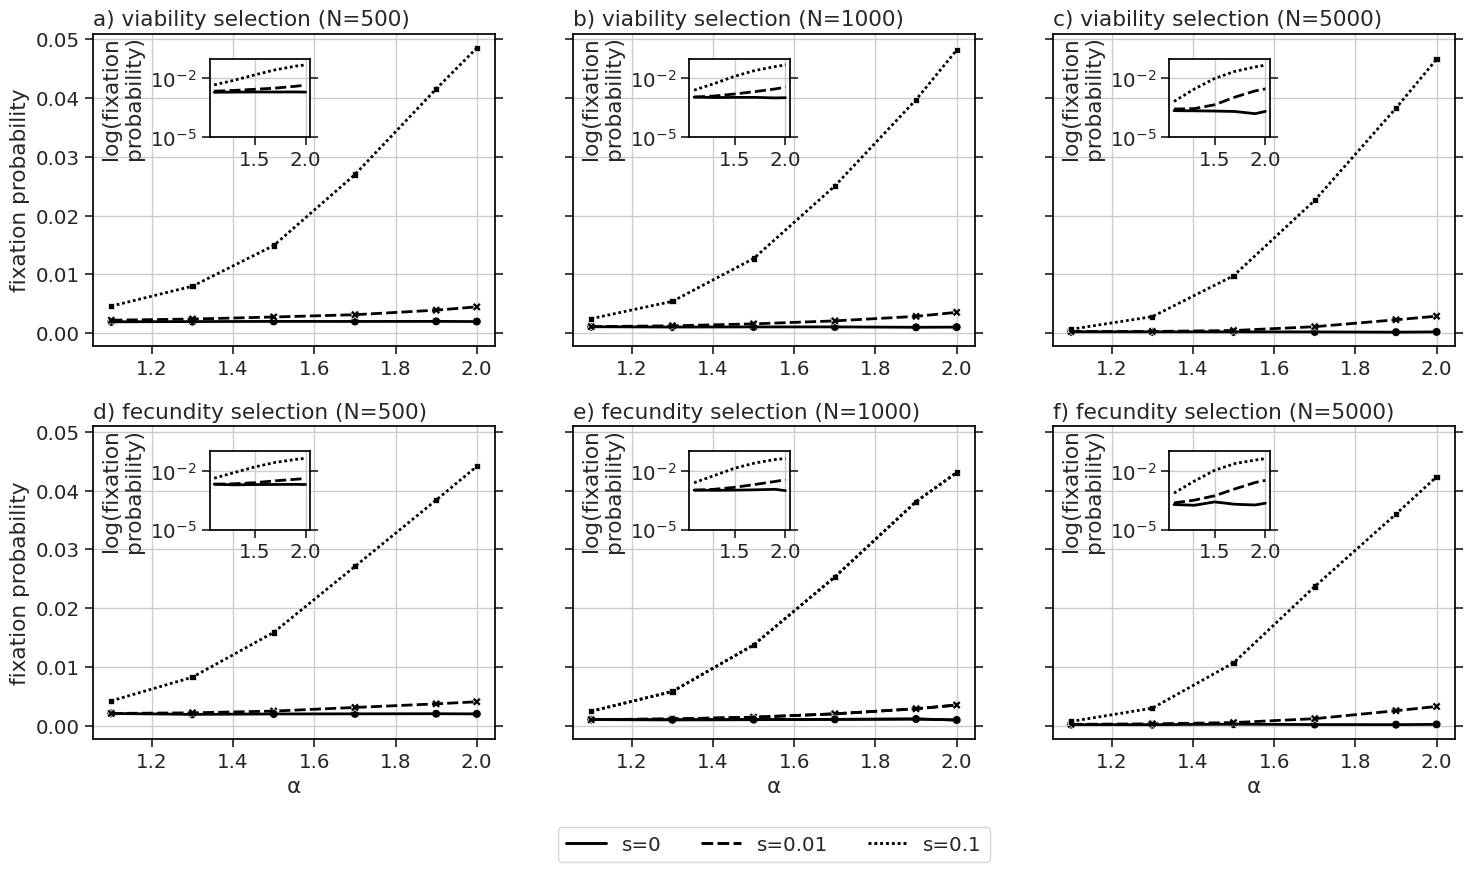

In [9]:
sns.set_style("whitegrid", {'axes.edgecolor' : '.0001'})

fig, axs = plt.subplots(2, 3, figsize=(15, 9), sharey=True)

colors = ["#03045e", "#0077b6", "#00b4d8"]
colors = "black"
color = "black"
linewidth = 2

for i, population_size in enumerate([500, 1000, 5000]):
    ax = axs[0][i]
    viability_constant_population_size = df = viability_constant_df[viability_constant_df["population_size"] == population_size]
    sns.lineplot(data=viability_constant_population_size, x="parameter", y="fixation_probability", style="selection_coefficient", ax=ax,
                 palette=colors, linewidth=linewidth, legend=False,  color = color)
    sns.scatterplot(data=viability_constant_population_size, x="parameter", y="fixation_probability", style="selection_coefficient", ax=ax,
                    palette=colors, s=40, legend=False,  color = color).set_title(pos_to_char(i) + ") viability selection (N=" + str(population_size) + ")",  loc="left")

    
    ins = axs[0][i].inset_axes([0.29, 0.67, 0.25, 0.25])
    sns.lineplot(data=viability_constant_population_size,x="parameter", y="fixation_probability", style="selection_coefficient", ax=ins,
                 palette=colors, linewidth=linewidth, legend=False,  color = color)
    
    
    ins.set_yscale("log")
    ins.set(ylim=(0.00001, 0.1), xlabel='', ylabel='log(fixation\nprobability)')
    ins.patch.set_edgecolor('black')  
    #ins.patch.set_linewidth('2')
    ins.tick_params(bottom=True, top=False, left=True, right=True)
    

    
    ax.tick_params(bottom=True, top=False, left=True, right=True)
    ax.patch.set_edgecolor('black')  
    #ax.grid(True)
    #ax.patch.set_linewidth('2')
    ax.set(xlabel='', ylabel='fixation probability')
    
    
    ax = axs[1][i]
    fecundity_constant_population_size = df = fecundity_constant_df[fecundity_constant_df["population_size"] == population_size]
    
    sns.lineplot(data=fecundity_constant_population_size, x="parameter", y="fixation_probability", style="selection_coefficient", ax=ax,
                 palette=colors, linewidth=linewidth, legend=False,  color = color)
    
    if i == 1:
        ax = sns.lineplot(data=fecundity_constant_population_size, x="parameter", y="fixation_probability", style="selection_coefficient", ax=ax, linewidth=linewidth, legend=True, color = color)

            
    sns.scatterplot(data=fecundity_constant_population_size, x="parameter", y="fixation_probability", style="selection_coefficient", ax=ax, palette=colors, s=40, legend=False, color = color).set_title(pos_to_char(i+3) + ") fecundity selection (N=" + str(population_size) + ")", loc="left")

    
    ins = axs[1][i].inset_axes([0.29, 0.67, 0.25, 0.25])
    sns.lineplot(data=fecundity_constant_population_size,x="parameter", y="fixation_probability", style="selection_coefficient", ax=ins,
                 palette=colors, linewidth=linewidth, legend=False,  color = color)

    ins.set_yscale("log")
    ins.set(ylim=(0.00001, 0.1), xlabel='', ylabel='log(fixation\nprobability)')
    ins.patch.set_edgecolor('black')  
    ins.tick_params(bottom=True, top=False, left=True, right=True)
    #ins.patch.set_linewidth('2')
    
    ax.tick_params(bottom=True, top=False, left=True, right=True)
    ax.patch.set_edgecolor('black')  
    ax.grid(True)
    #ax.patch.set_linewidth('2')
    ax.set(xlabel='α', ylabel='fixation probability')
    

legend_pos=-0.25    
ncol=3
ax=axs[1][1]
box = ax.get_position()
h, l = ax.get_legend_handles_labels()
leg = ax.legend(handles=h, loc='upper center',bbox_to_anchor=(0.5, legend_pos), fancybox=True, shadow=False, ncol=ncol, labels=["s=0","s=0.01","s=0.1"])
for line in leg.get_lines():
    line.set_linewidth(2.1) 
            

plt.tight_layout()
plt.savefig("./figures/probability_fixation_population_constant_selection_constant.pdf", dpi=500)

## (3) Difference between viability and fecundity selection (constant population size)

In [52]:
files = os.listdir("../src/simulations/")
files = ["../src/simulations/" + file for file in files]
# filter the times
df_time = [pd.read_csv(file) for file in files if "probability" in file]
df_time = pd.concat(df_time).reset_index()
df = df_time[df_time["population_size_model"] == "constant"]

In [53]:
fecundity_constant = df[df["selection_type"] == "fecundity_constant"]
viability_constant = df[df["selection_type"] == "viability_constant"]

selection_coefficients = [0, 0.01, 0.1]
population_sizes = [500, 1000, 5000]

difference_frame = []

for population_size in population_sizes:

    for selection_coefficient in selection_coefficients:

        constant = pd.concat([fecundity_constant, viability_constant]).reset_index()
        constant = constant[constant["population_size"] == population_size]
        constant = constant[constant["selection_coefficient"] == selection_coefficient]

        for alpha in [1.1, 1.3, 1.5, 1.7, 1.9, 2.0]:
            try:
                alpha_frame = constant[constant["parameter"] == alpha]
                fc = alpha_frame[alpha_frame["selection_type"] == "fecundity_constant"]
                vc = alpha_frame[alpha_frame["selection_type"] == "viability_constant"]
                diff = fc.fixation_probability.item() - vc.fixation_probability.item()
                #diff_std = np.mean([fc.standard_deviation.item(), vc.standard_deviation.item()])
                #print(alpha, diff, population_size, selection_coefficient)

                difference_frame.append([alpha, diff, population_size, selection_coefficient])
            except:
                print(population_size, selection_coefficient, alpha)
difference_frame = pd.DataFrame(difference_frame, columns=["alpha", "fecundity-viability", "population_size", "selection_coefficient"])

500 0 1.3
500 0 1.5
500 0 1.7
500 0 1.9
500 0 2.0
500 0.01 1.3
500 0.01 1.5
500 0.01 1.7
500 0.01 1.9
500 0.01 2.0
500 0.1 1.3
500 0.1 1.5
500 0.1 1.7
500 0.1 1.9
500 0.1 2.0
1000 0 1.3
1000 0 1.5
1000 0 1.7
1000 0 1.9
1000 0 2.0
1000 0.01 1.3
1000 0.01 1.5
1000 0.01 1.7
1000 0.01 1.9
1000 0.01 2.0
1000 0.1 1.3
1000 0.1 1.5
1000 0.1 1.7
1000 0.1 1.9
1000 0.1 2.0
5000 0 1.3
5000 0 1.5
5000 0 1.7
5000 0 1.9
5000 0 2.0
5000 0.01 1.3
5000 0.01 1.5
5000 0.01 1.7
5000 0.01 1.9
5000 0.01 2.0
5000 0.1 1.3
5000 0.1 1.5
5000 0.1 1.7
5000 0.1 1.9
5000 0.1 2.0


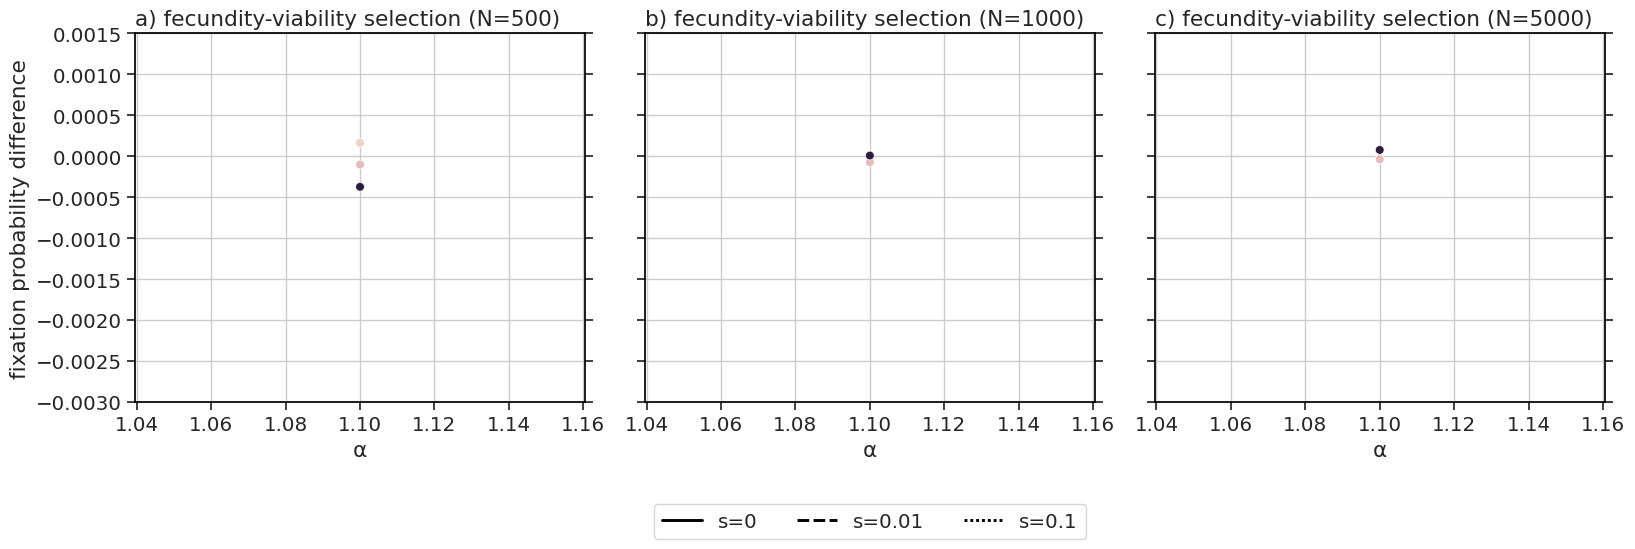

In [54]:
sns.set_style("whitegrid", {'axes.edgecolor' : '.0001'})

fig, axs = plt.subplots(1, 3, figsize=(16.5, 6), sharey=True)

colors = ["#03045e", "#0077b6", "#00b4d8"]
colors = "black"
color = "black"
linewidth = 2


for i, population_size in enumerate(population_sizes):
    difference_frame_population__size = difference_frame[difference_frame["population_size"] == population_size]
    ax = axs[i]
    if i != 1:
        sns.lineplot(data=difference_frame_population__size, x="alpha", y="fecundity-viability",linewidth=2, style="selection_coefficient", ax=ax, color=color, legend=False)
    else:
        sns.lineplot(data=difference_frame_population__size, x="alpha", y="fecundity-viability",linewidth=2, style="selection_coefficient", ax=ax, color=colors)

    sns.scatterplot(data=difference_frame_population__size, x="alpha", y="fecundity-viability",
                    s=40, hue="selection_coefficient", ax=ax, legend=False, color=color).set_title(pos_to_char(i) + ") fecundity-viability selection (N=" + str(population_size) + ")", loc="left")
    ax.set(xlabel='α', ylabel='fixation probability difference')
    ax.grid(True)
    ax.tick_params(bottom=True, top=False, left=True, right=True)
    ax.patch.set_edgecolor('black')  
    #ax.patch.set_linewidth('2') 
    ax.set_ylim(-0.003, 0.0015)

legend_pos=-0.25    
ncol=3
ax=axs[1]
box = ax.get_position()
h, l = ax.get_legend_handles_labels()
leg = ax.legend(handles=h, loc='upper center',bbox_to_anchor=(0.5, legend_pos), fancybox=True, shadow=False, ncol=ncol, labels=["s=0","s=0.01","s=0.1"])
for line in leg.get_lines():
    line.set_linewidth(2.1) 

plt.tight_layout()
plt.savefig("./figures/difference_probability_fixation_population_constant_selection_constant.pdf", dpi=500)


## (4) Viability selection (sinus population size), (5) Fecundity selection (sinus population size)

In [14]:
files = os.listdir("../src/simulations/")
files = ["../src/simulations/" + file for file in files]
# filter the times
df_time = [pd.read_csv(file) for file in files if "probability" in file and "shifted_0.0" in file]
df_time = pd.concat(df_time).reset_index()
df = df_time[df_time["population_size_model"] == "sinus"]

In [15]:
viability_constant_df = df[df["selection_type"] == "viability_constant"].reset_index()
fecundity_constant_df = df[df["selection_type"] == "fecundity_constant"].reset_index()
selection_coefficients = viability_constant_df.selection_coefficient.unique().tolist() 

In [16]:
sinus_population_size = sorted(df.population_size.unique().tolist()); sinus_population_size

sinus_population_size

[578, 1156, 5777]

/tmp/ipykernel_2960852/2777866840.py:14: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=viability_constant_population_size, x="parameter", y="fixation_probability", style="selection_coefficient", ax=ax,
/tmp/ipykernel_2960852/2777866840.py:16: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=viability_constant_population_size, x="parameter", y="fixation_probability", style="selection_coefficient", ax=ax,
/tmp/ipykernel_2960852/2777866840.py:21: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=viability_constant_population_size,x="parameter", y="fixation_probability", style="selection_coefficient", ax=ins,
/tmp/ipykernel_2960852/2777866840.py:43: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=fecundity_constant_population_size, x="parameter", y="fixation_probability", style="selection_coeffi

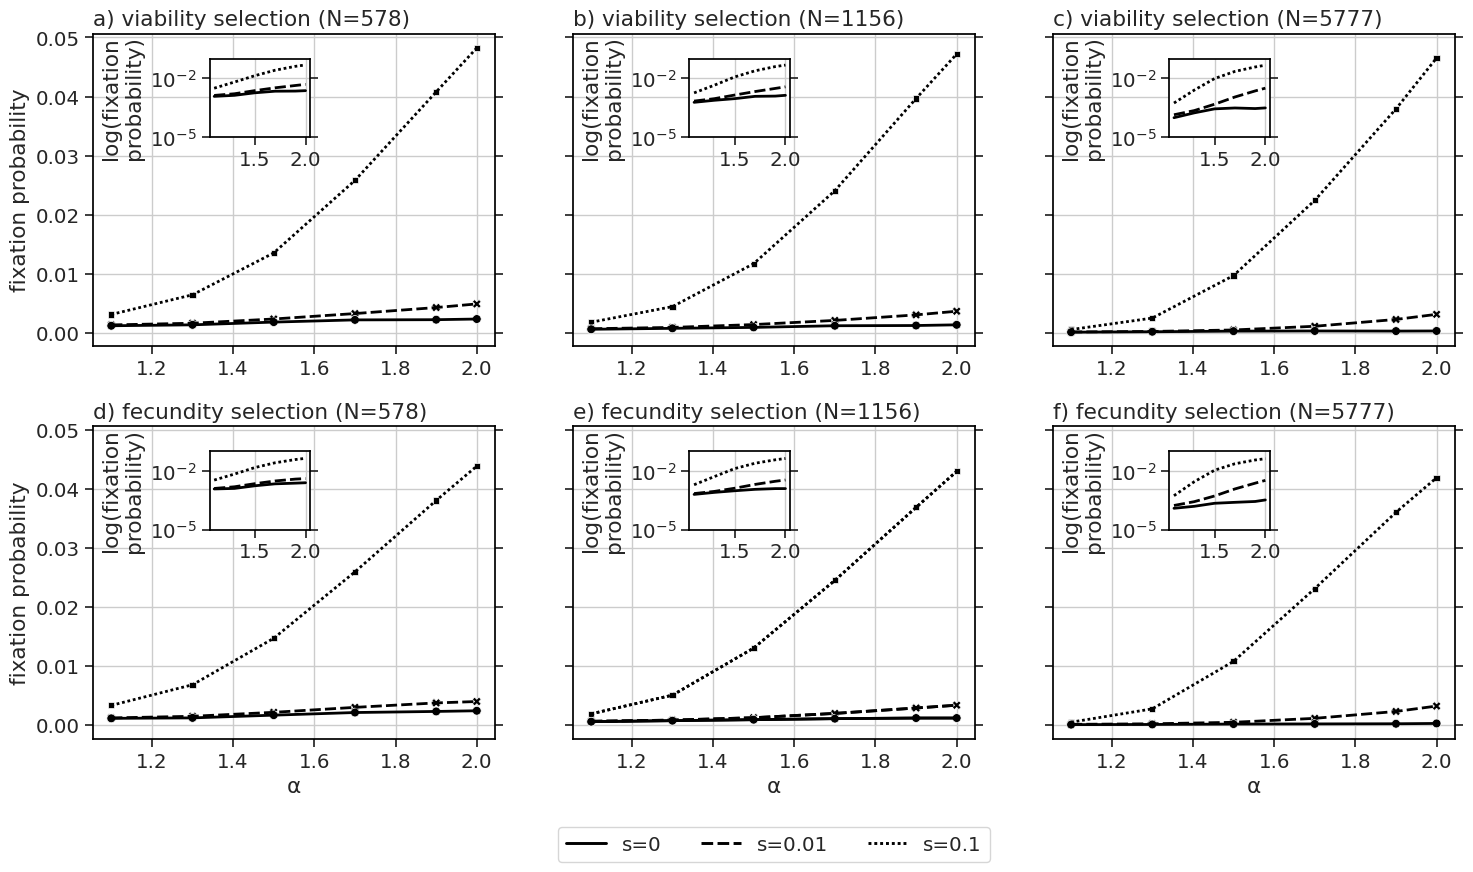

In [17]:
sns.set(font_scale = 1.3, style="whitegrid")
sns.set_style("whitegrid", {'axes.edgecolor' : '.0001'})

fig, axs = plt.subplots(2, 3, figsize=(15, 9), sharey=True)

colors = ["#03045e", "#0077b6", "#00b4d8"]
colors = "black"
color = "black"
linewidth = 2

for i, population_size in enumerate(sinus_population_size):
    ax = axs[0][i]
    viability_constant_population_size = df = viability_constant_df[viability_constant_df["population_size"] == population_size]
    sns.lineplot(data=viability_constant_population_size, x="parameter", y="fixation_probability", style="selection_coefficient", ax=ax,
                 palette=colors, linewidth=linewidth, legend=False,  color = color)
    sns.scatterplot(data=viability_constant_population_size, x="parameter", y="fixation_probability", style="selection_coefficient", ax=ax,
                    palette=colors, s=40, legend=False,  color = color).set_title(pos_to_char(i) + ") viability selection (N=" + str(population_size) + ")",  loc="left")

    
    ins = axs[0][i].inset_axes([0.29, 0.67, 0.25, 0.25])
    sns.lineplot(data=viability_constant_population_size,x="parameter", y="fixation_probability", style="selection_coefficient", ax=ins,
                 palette=colors, linewidth=linewidth, legend=False,  color = color)
    
    
    ins.set_yscale("log")
    ins.set(ylim=(0.00001, 0.1), xlabel='', ylabel='log(fixation\nprobability)')
    ins.patch.set_edgecolor('black')  
    #ins.patch.set_linewidth('2')
    ins.tick_params(bottom=True, top=False, left=True, right=True)
    

    
    ax.tick_params(bottom=True, top=False, left=True, right=True)
    ax.patch.set_edgecolor('black')  
    #ax.grid(True)
    #ax.patch.set_linewidth('2')
    ax.set(xlabel='', ylabel='fixation probability')
    
    
    ax = axs[1][i]
    fecundity_constant_population_size = df = fecundity_constant_df[fecundity_constant_df["population_size"] == population_size]
    
    sns.lineplot(data=fecundity_constant_population_size, x="parameter", y="fixation_probability", style="selection_coefficient", ax=ax,
                 palette=colors, linewidth=linewidth, legend=False,  color = color)
    
    if i == 1:
        ax = sns.lineplot(data=fecundity_constant_population_size, x="parameter", y="fixation_probability", style="selection_coefficient", ax=ax, linewidth=linewidth, legend=True, color = color)

            
    sns.scatterplot(data=fecundity_constant_population_size, x="parameter", y="fixation_probability", style="selection_coefficient", ax=ax, palette=colors, s=40, legend=False, color = color).set_title(pos_to_char(i+3) + ") fecundity selection (N=" + str(population_size) + ")", loc="left")

    
    ins = axs[1][i].inset_axes([0.29, 0.67, 0.25, 0.25])
    sns.lineplot(data=fecundity_constant_population_size,x="parameter", y="fixation_probability", style="selection_coefficient", ax=ins,
                 palette=colors, linewidth=linewidth, legend=False,  color = color)

    ins.set_yscale("log")
    ins.set(ylim=(0.00001, 0.1), xlabel='', ylabel='log(fixation\nprobability)')
    ins.patch.set_edgecolor('black')  
    ins.tick_params(bottom=True, top=False, left=True, right=True)
    #ins.patch.set_linewidth('2')
    
    ax.tick_params(bottom=True, top=False, left=True, right=True)
    ax.patch.set_edgecolor('black')  
    ax.grid(True)
    #ax.patch.set_linewidth('2')
    ax.set(xlabel='α', ylabel='fixation probability')
    

legend_pos=-0.25    
ncol=3
ax=axs[1][1]
box = ax.get_position()
h, l = ax.get_legend_handles_labels()
leg = ax.legend(handles=h, loc='upper center',bbox_to_anchor=(0.5, legend_pos), fancybox=True, shadow=False, ncol=ncol, labels=["s=0","s=0.01","s=0.1"])
for line in leg.get_lines():
    line.set_linewidth(2.1) 
            

plt.tight_layout()
plt.savefig("./figures/probability_fixation_population_sinus_selection_constant.pdf", dpi=500)


/tmp/ipykernel_2960852/2556738225.py:16: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=viability_constant_population_size, x="parameter", y="fixation_probability", style="selection_coefficient", ax=ax,
/tmp/ipykernel_2960852/2556738225.py:18: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=viability_constant_population_size, x="parameter", y="fixation_probability", style="selection_coefficient", ax=ax,
/tmp/ipykernel_2960852/2556738225.py:23: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=viability_constant_population_size,x="parameter", y="fixation_probability", style="selection_coefficient", ax=ins,
/tmp/ipykernel_2960852/2556738225.py:45: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=fecundity_constant_population_size, x="parameter", y="fixation_probability", style="selection_coeffi

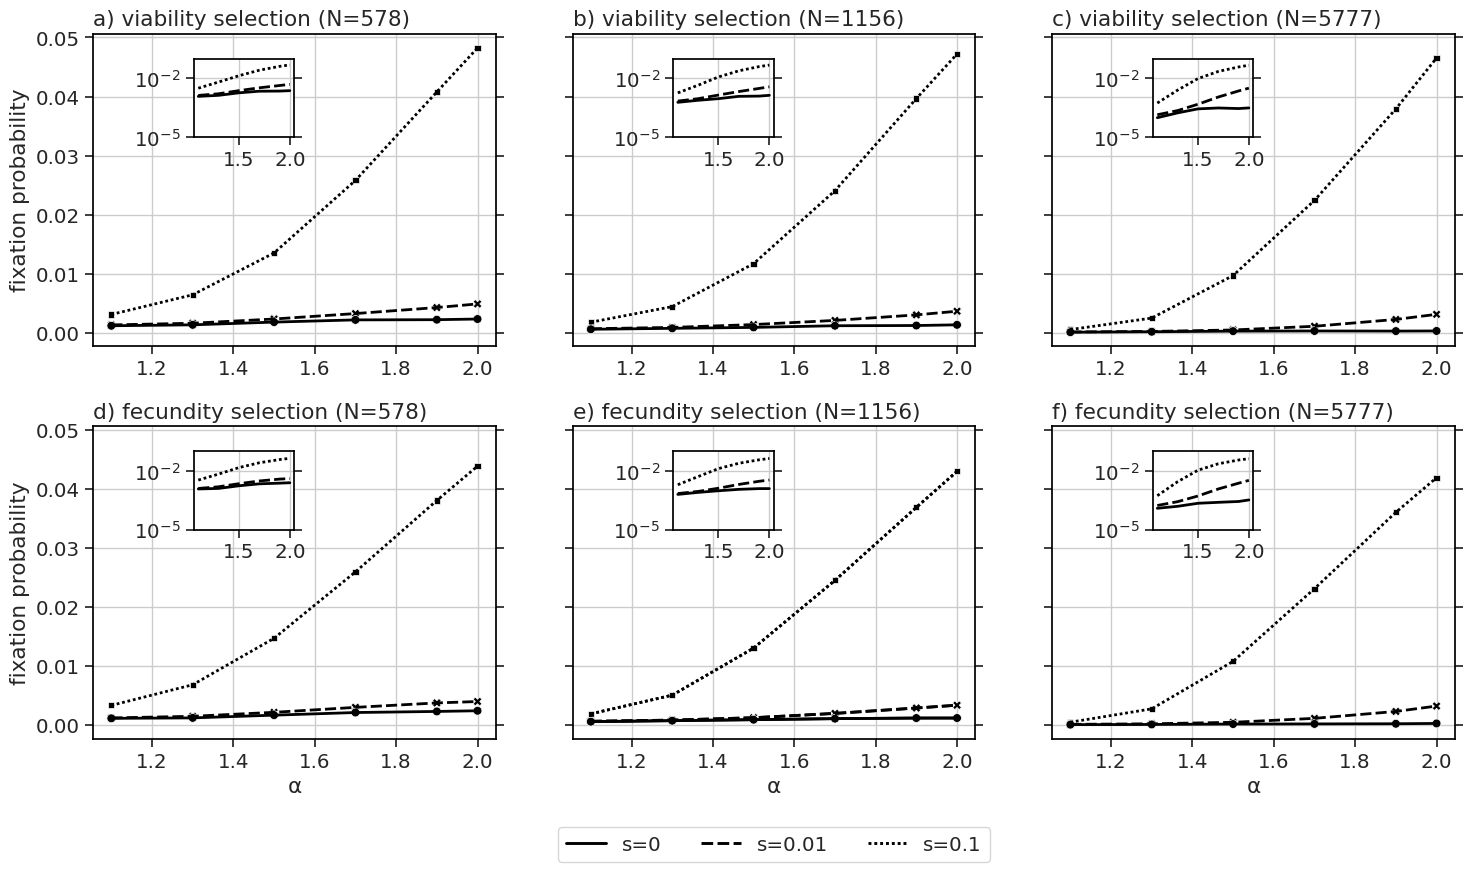

In [18]:
# new 

sns.set(font_scale = 1.3, style="whitegrid")
sns.set_style("whitegrid", {'axes.edgecolor' : '.0001'})

fig, axs = plt.subplots(2, 3, figsize=(15, 9), sharey=True)

colors = ["#03045e", "#0077b6", "#00b4d8"]
colors = "black"
color = "black"
linewidth = 2

for i, population_size in enumerate(sinus_population_size):
    ax = axs[0][i]
    viability_constant_population_size = df = viability_constant_df[viability_constant_df["population_size"] == population_size]
    sns.lineplot(data=viability_constant_population_size, x="parameter", y="fixation_probability", style="selection_coefficient", ax=ax,
                 palette=colors, linewidth=linewidth, legend=False,  color = color)
    sns.scatterplot(data=viability_constant_population_size, x="parameter", y="fixation_probability", style="selection_coefficient", ax=ax,
                    palette=colors, s=40, legend=False,  color = color).set_title(pos_to_char(i) + ") viability selection (N=" + str(population_size) + ")",  loc="left")

    
    ins = axs[0][i].inset_axes([0.25, 0.67, 0.25, 0.25])
    sns.lineplot(data=viability_constant_population_size,x="parameter", y="fixation_probability", style="selection_coefficient", ax=ins,
                 palette=colors, linewidth=linewidth, legend=False,  color = color)
    
    
    ins.set_yscale("log")
    ins.set(ylim=(0.00001, 0.1), xlabel='', ylabel='')
    ins.patch.set_edgecolor('black')  
    #ins.patch.set_linewidth('2')
    ins.tick_params(bottom=True, top=False, left=True, right=True)
    

    
    ax.tick_params(bottom=True, top=False, left=True, right=True)
    ax.patch.set_edgecolor('black')  
    #ax.grid(True)
    #ax.patch.set_linewidth('2')
    ax.set(xlabel='', ylabel='fixation probability')
    
    
    ax = axs[1][i]
    fecundity_constant_population_size = df = fecundity_constant_df[fecundity_constant_df["population_size"] == population_size]
    
    sns.lineplot(data=fecundity_constant_population_size, x="parameter", y="fixation_probability", style="selection_coefficient", ax=ax,
                 palette=colors, linewidth=linewidth, legend=False,  color = color)
    
    if i == 1:
        ax = sns.lineplot(data=fecundity_constant_population_size, x="parameter", y="fixation_probability", style="selection_coefficient", ax=ax, linewidth=linewidth, legend=True, color = color)

            
    sns.scatterplot(data=fecundity_constant_population_size, x="parameter", y="fixation_probability", style="selection_coefficient", ax=ax, palette=colors, s=40, legend=False, color = color).set_title(pos_to_char(i+3) + ") fecundity selection (N=" + str(population_size) + ")", loc="left")

    
    ins = axs[1][i].inset_axes([0.25, 0.67, 0.25, 0.25])
    sns.lineplot(data=fecundity_constant_population_size,x="parameter", y="fixation_probability", style="selection_coefficient", ax=ins,
                 palette=colors, linewidth=linewidth, legend=False,  color = color)

    ins.set_yscale("log")
    ins.set(ylim=(0.00001, 0.1), xlabel='', ylabel='')
    ins.patch.set_edgecolor('black')  
    ins.tick_params(bottom=True, top=False, left=True, right=True)
    #ins.patch.set_linewidth('2')
    
    ax.tick_params(bottom=True, top=False, left=True, right=True)
    ax.patch.set_edgecolor('black')  
    ax.grid(True)
    #ax.patch.set_linewidth('2')
    ax.set(xlabel='α', ylabel='fixation probability')
    

legend_pos=-0.25    
ncol=3
ax=axs[1][1]
box = ax.get_position()
h, l = ax.get_legend_handles_labels()
leg = ax.legend(handles=h, loc='upper center',bbox_to_anchor=(0.5, legend_pos), fancybox=True, shadow=False, ncol=ncol, labels=["s=0","s=0.01","s=0.1"])
for line in leg.get_lines():
    line.set_linewidth(2.1) 
            

plt.tight_layout()
plt.savefig("./figures/probability_fixation_population_sinus_selection_constant.pdf", dpi=500)

## (6) Viability selection (shifted sinus population size), (7) Fecundity selection (shifted sinus population size)

In [19]:
files = os.listdir("../src/simulations/")
files = ["../src/simulations/" + file for file in files]
# filter the times
df_time = [pd.read_csv(file) for file in files if "probability" in file and "shifted_3.1" in file]
df_time = pd.concat(df_time).reset_index()
df = df_time[df_time["population_size_model"] == "sinus"]

In [20]:
viability_constant_df = df[df["selection_type"] == "viability_constant"].reset_index()
fecundity_constant_df = df[df["selection_type"] == "fecundity_constant"].reset_index()
selection_coefficients = viability_constant_df.selection_coefficient.unique().tolist() 

In [21]:
sinus_population_size = sorted(df.population_size.unique().tolist()); sinus_population_size

[578, 1156, 5777]

/tmp/ipykernel_2960852/721311367.py:14: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=viability_constant_population_size, x="parameter", y="fixation_probability", style="selection_coefficient", ax=ax,
/tmp/ipykernel_2960852/721311367.py:16: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=viability_constant_population_size, x="parameter", y="fixation_probability", style="selection_coefficient", ax=ax,
/tmp/ipykernel_2960852/721311367.py:21: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=viability_constant_population_size,x="parameter", y="fixation_probability", style="selection_coefficient", ax=ins,
/tmp/ipykernel_2960852/721311367.py:43: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=fecundity_constant_population_size, x="parameter", y="fixation_probability", style="selection_coefficien

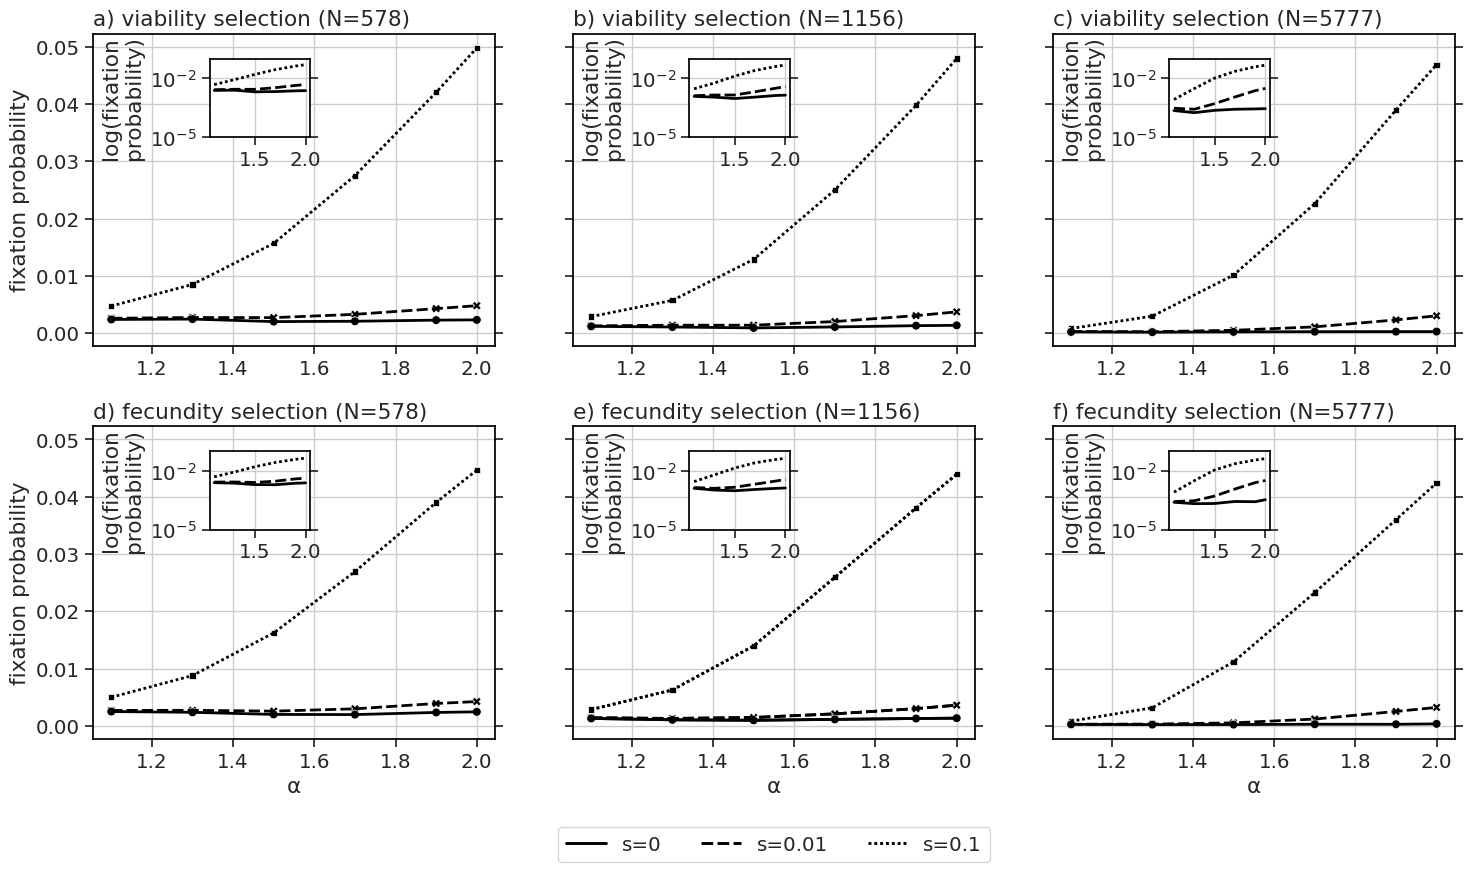

In [22]:
sns.set(font_scale = 1.3, style="whitegrid")
sns.set_style("whitegrid", {'axes.edgecolor' : '.0001'})

fig, axs = plt.subplots(2, 3, figsize=(15, 9), sharey=True)

colors = ["#03045e", "#0077b6", "#00b4d8"]
colors = "black"
color = "black"
linewidth = 2

for i, population_size in enumerate(sinus_population_size):
    ax = axs[0][i]
    viability_constant_population_size = df = viability_constant_df[viability_constant_df["population_size"] == population_size]
    sns.lineplot(data=viability_constant_population_size, x="parameter", y="fixation_probability", style="selection_coefficient", ax=ax,
                 palette=colors, linewidth=linewidth, legend=False,  color = color)
    sns.scatterplot(data=viability_constant_population_size, x="parameter", y="fixation_probability", style="selection_coefficient", ax=ax,
                    palette=colors, s=40, legend=False,  color = color).set_title(pos_to_char(i) + ") viability selection (N=" + str(population_size) + ")",  loc="left")

    
    ins = axs[0][i].inset_axes([0.29, 0.67, 0.25, 0.25])
    sns.lineplot(data=viability_constant_population_size,x="parameter", y="fixation_probability", style="selection_coefficient", ax=ins,
                 palette=colors, linewidth=linewidth, legend=False,  color = color)
    
    
    ins.set_yscale("log")
    ins.set(ylim=(0.00001, 0.1), xlabel='', ylabel='log(fixation\nprobability)')
    ins.patch.set_edgecolor('black')  
    #ins.patch.set_linewidth('2')
    ins.tick_params(bottom=True, top=False, left=True, right=True)
    

    
    ax.tick_params(bottom=True, top=False, left=True, right=True)
    ax.patch.set_edgecolor('black')  
    #ax.grid(True)
    #ax.patch.set_linewidth('2')
    ax.set(xlabel='', ylabel='fixation probability')
    
    
    ax = axs[1][i]
    fecundity_constant_population_size = df = fecundity_constant_df[fecundity_constant_df["population_size"] == population_size]
    
    sns.lineplot(data=fecundity_constant_population_size, x="parameter", y="fixation_probability", style="selection_coefficient", ax=ax,
                 palette=colors, linewidth=linewidth, legend=False,  color = color)
    
    if i == 1:
        ax = sns.lineplot(data=fecundity_constant_population_size, x="parameter", y="fixation_probability", style="selection_coefficient", ax=ax, linewidth=linewidth, legend=True, color = color)

            
    sns.scatterplot(data=fecundity_constant_population_size, x="parameter", y="fixation_probability", style="selection_coefficient", ax=ax, palette=colors, s=40, legend=False, color = color).set_title(pos_to_char(i+3) + ") fecundity selection (N=" + str(population_size) + ")", loc="left")

    
    ins = axs[1][i].inset_axes([0.29, 0.67, 0.25, 0.25])
    sns.lineplot(data=fecundity_constant_population_size,x="parameter", y="fixation_probability", style="selection_coefficient", ax=ins,
                 palette=colors, linewidth=linewidth, legend=False,  color = color)

    ins.set_yscale("log")
    ins.set(ylim=(0.00001, 0.1), xlabel='', ylabel='log(fixation\nprobability)')
    ins.patch.set_edgecolor('black')  
    ins.tick_params(bottom=True, top=False, left=True, right=True)
    #ins.patch.set_linewidth('2')
    
    ax.tick_params(bottom=True, top=False, left=True, right=True)
    ax.patch.set_edgecolor('black')  
    ax.grid(True)
    #ax.patch.set_linewidth('2')
    ax.set(xlabel='α', ylabel='fixation probability')
    

legend_pos=-0.25    
ncol=3
ax=axs[1][1]
box = ax.get_position()
h, l = ax.get_legend_handles_labels()
leg = ax.legend(handles=h, loc='upper center',bbox_to_anchor=(0.5, legend_pos), fancybox=True, shadow=False, ncol=ncol, labels=["s=0","s=0.01","s=0.1"])
for line in leg.get_lines():
    line.set_linewidth(2.1) 
            

plt.tight_layout()
plt.savefig("./figures/probability_fixation_population_shifted_sinus_selection_constant.pdf", dpi=500)


/tmp/ipykernel_2960852/1810361939.py:14: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=viability_constant_population_size, x="parameter", y="fixation_probability", style="selection_coefficient", ax=ax,
/tmp/ipykernel_2960852/1810361939.py:16: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=viability_constant_population_size, x="parameter", y="fixation_probability", style="selection_coefficient", ax=ax,
/tmp/ipykernel_2960852/1810361939.py:21: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=viability_constant_population_size,x="parameter", y="fixation_probability", style="selection_coefficient", ax=ins,
/tmp/ipykernel_2960852/1810361939.py:43: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=fecundity_constant_population_size, x="parameter", y="fixation_probability", style="selection_coeffi

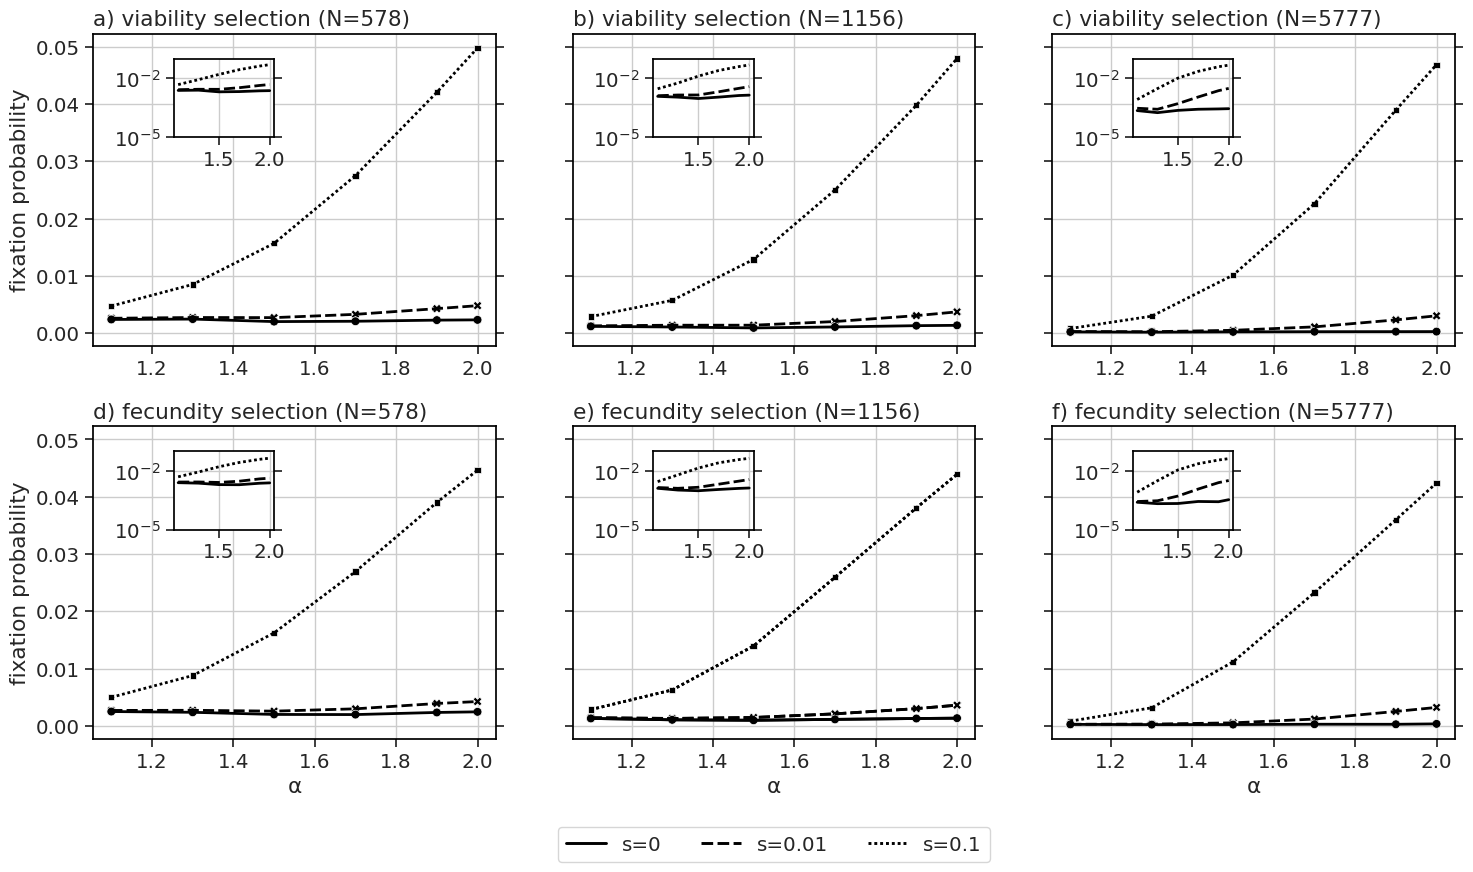

In [23]:
sns.set(font_scale = 1.3, style="whitegrid")
sns.set_style("whitegrid", {'axes.edgecolor' : '.0001'})

fig, axs = plt.subplots(2, 3, figsize=(15, 9), sharey=True)

colors = ["#03045e", "#0077b6", "#00b4d8"]
colors = "black"
color = "black"
linewidth = 2

for i, population_size in enumerate(sinus_population_size):
    ax = axs[0][i]
    viability_constant_population_size = df = viability_constant_df[viability_constant_df["population_size"] == population_size]
    sns.lineplot(data=viability_constant_population_size, x="parameter", y="fixation_probability", style="selection_coefficient", ax=ax,
                 palette=colors, linewidth=linewidth, legend=False,  color = color)
    sns.scatterplot(data=viability_constant_population_size, x="parameter", y="fixation_probability", style="selection_coefficient", ax=ax,
                    palette=colors, s=40, legend=False,  color = color).set_title(pos_to_char(i) + ") viability selection (N=" + str(population_size) + ")",  loc="left")

    
    ins = axs[0][i].inset_axes([0.2, 0.67, 0.25, 0.25])
    sns.lineplot(data=viability_constant_population_size,x="parameter", y="fixation_probability", style="selection_coefficient", ax=ins,
                 palette=colors, linewidth=linewidth, legend=False,  color = color)
    
    
    ins.set_yscale("log")
    ins.set(ylim=(0.00001, 0.1), xlabel='', ylabel='')
    ins.patch.set_edgecolor('black')  
    #ins.patch.set_linewidth('2')
    ins.tick_params(bottom=True, top=False, left=True, right=True)
    

    
    ax.tick_params(bottom=True, top=False, left=True, right=True)
    ax.patch.set_edgecolor('black')  
    #ax.grid(True)
    #ax.patch.set_linewidth('2')
    ax.set(xlabel='', ylabel='fixation probability')
    
    
    ax = axs[1][i]
    fecundity_constant_population_size = df = fecundity_constant_df[fecundity_constant_df["population_size"] == population_size]
    
    sns.lineplot(data=fecundity_constant_population_size, x="parameter", y="fixation_probability", style="selection_coefficient", ax=ax,
                 palette=colors, linewidth=linewidth, legend=False,  color = color)
    
    if i == 1:
        ax = sns.lineplot(data=fecundity_constant_population_size, x="parameter", y="fixation_probability", style="selection_coefficient", ax=ax, linewidth=linewidth, legend=True, color = color)

            
    sns.scatterplot(data=fecundity_constant_population_size, x="parameter", y="fixation_probability", style="selection_coefficient", ax=ax, palette=colors, s=40, legend=False, color = color).set_title(pos_to_char(i+3) + ") fecundity selection (N=" + str(population_size) + ")", loc="left")

    
    ins = axs[1][i].inset_axes([0.2, 0.67, 0.25, 0.25])
    sns.lineplot(data=fecundity_constant_population_size,x="parameter", y="fixation_probability", style="selection_coefficient", ax=ins,
                 palette=colors, linewidth=linewidth, legend=False,  color = color)

    ins.set_yscale("log")
    ins.set(ylim=(0.00001, 0.1), xlabel='', ylabel='')
    ins.patch.set_edgecolor('black')  
    ins.tick_params(bottom=True, top=False, left=True, right=True)
    #ins.patch.set_linewidth('2')
    
    ax.tick_params(bottom=True, top=False, left=True, right=True)
    ax.patch.set_edgecolor('black')  
    ax.grid(True)
    #ax.patch.set_linewidth('2')
    ax.set(xlabel='α', ylabel='fixation probability')
    

legend_pos=-0.25    
ncol=3
ax=axs[1][1]
box = ax.get_position()
h, l = ax.get_legend_handles_labels()
leg = ax.legend(handles=h, loc='upper center',bbox_to_anchor=(0.5, legend_pos), fancybox=True, shadow=False, ncol=ncol, labels=["s=0","s=0.01","s=0.1"])
for line in leg.get_lines():
    line.set_linewidth(2.1) 
            

plt.tight_layout()
plt.savefig("./figures/probability_fixation_population_shifted_sinus_selection_constant.pdf", dpi=500)


## (8) Difference between viability and fecundity selection (sinus population size)

In [24]:
files = os.listdir("../src/simulations/")
files = ["../src/simulations/" + file for file in files]
# filter the times
df_time = [pd.read_csv(file) for file in files if "probability" in file and "shifted_0.0" in file]
df_time = pd.concat(df_time).reset_index()
df = df_time[df_time["population_size_model"] == "sinus"]

In [25]:
fecundity_constant = df[df["selection_type"] == "fecundity_constant"]
viability_constant = df[df["selection_type"] == "viability_constant"]

selection_coefficients = [0, 0.01, 0.1]

difference_frame = []
for population_size in sinus_population_size:

    for selection_coefficient in selection_coefficients:
        
        constant = pd.concat([fecundity_constant, viability_constant]).reset_index()
        constant = constant[constant["population_size"] == population_size]
        constant = constant[constant["selection_coefficient"] == selection_coefficient]

        for alpha in [1.1, 1.3, 1.5, 1.7, 1.9, 2.0]:
            try:
                alpha_frame = constant[constant["parameter"] == alpha]
                fc = alpha_frame[alpha_frame["selection_type"] == "fecundity_constant"]
                vc = alpha_frame[alpha_frame["selection_type"] == "viability_constant"]
                diff = fc.fixation_probability.item() - vc.fixation_probability.item()
                #diff_std = np.mean([fc.standard_deviation.item(), vc.standard_deviation.item()])
                #print(alpha, diff, population_size, selection_coefficient)

                difference_frame.append([alpha, diff, population_size, selection_coefficient])
            except:
                print(population_size, selection_coefficient, alpha)
            
difference_frame = pd.DataFrame(difference_frame, columns=["alpha", "fecundity-viability", "population_size", "selection_coefficient"])

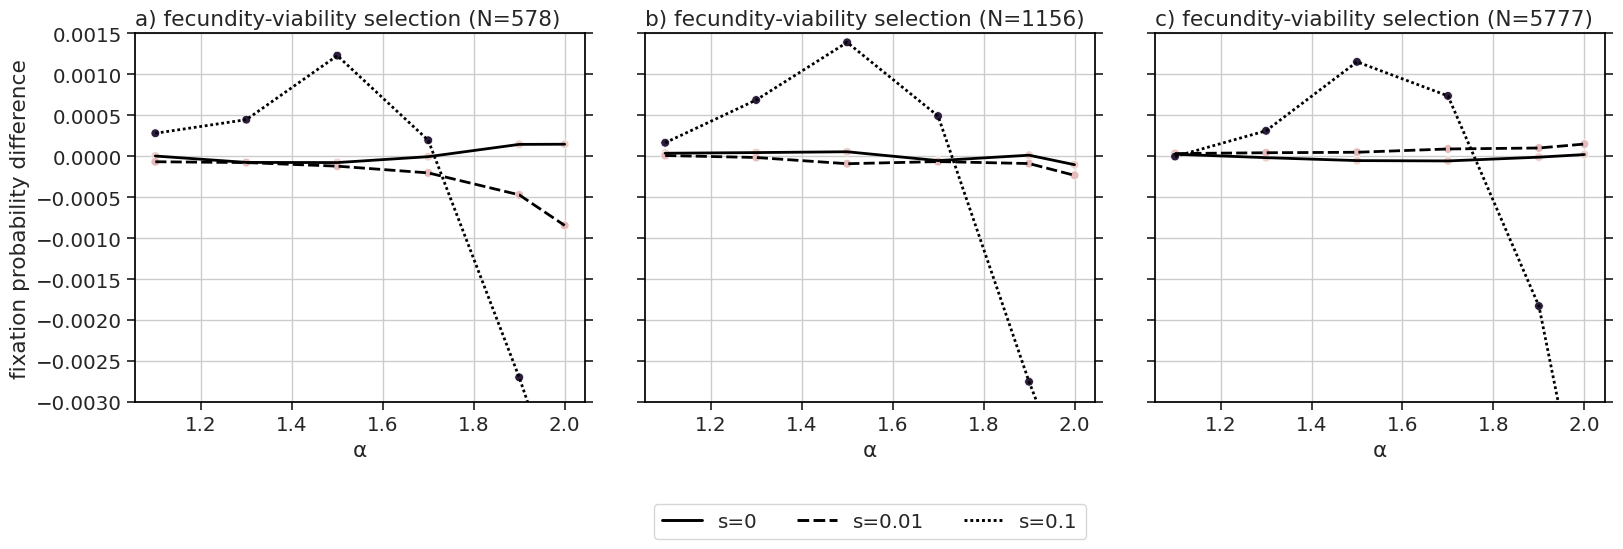

In [26]:
sns.set_style("whitegrid", {'axes.edgecolor' : '.0001'})

fig, axs = plt.subplots(1, 3, figsize=(16.5, 6), sharey=True)

colors = ["#03045e", "#0077b6", "#00b4d8"]
colors = "black"
color = "black"
linewidth = 2


for i, population_size in enumerate(sinus_population_size):
    difference_frame_population__size = difference_frame[difference_frame["population_size"] == population_size]
    ax = axs[i]
    if i != 1:
        sns.lineplot(data=difference_frame_population__size, x="alpha", y="fecundity-viability",linewidth=2, style="selection_coefficient", ax=ax, color=color, legend=False)
    else:
        sns.lineplot(data=difference_frame_population__size, x="alpha", y="fecundity-viability",linewidth=2, style="selection_coefficient", ax=ax, color=colors)

    sns.scatterplot(data=difference_frame_population__size, x="alpha", y="fecundity-viability",
                    s=40, hue="selection_coefficient", ax=ax, legend=False, color=color).set_title(pos_to_char(i) + ") fecundity-viability selection (N=" + str(population_size) + ")", loc="left")
    ax.set(xlabel='α', ylabel='fixation probability difference')
    ax.grid(True)
    ax.tick_params(bottom=True, top=False, left=True, right=True)
    ax.patch.set_edgecolor('black')  
    #ax.patch.set_linewidth('2') 
    ax.set_ylim(-0.003, 0.0015)

legend_pos=-0.25    
ncol=3
ax=axs[1]
box = ax.get_position()
h, l = ax.get_legend_handles_labels()
leg = ax.legend(handles=h, loc='upper center',bbox_to_anchor=(0.5, legend_pos), fancybox=True, shadow=False, ncol=ncol, labels=["s=0","s=0.01","s=0.1"])
for line in leg.get_lines():
    line.set_linewidth(2.1) 

plt.tight_layout()
plt.savefig("./figures/difference_probability_fixation_population_sinus_selection_constant.pdf", dpi=500)


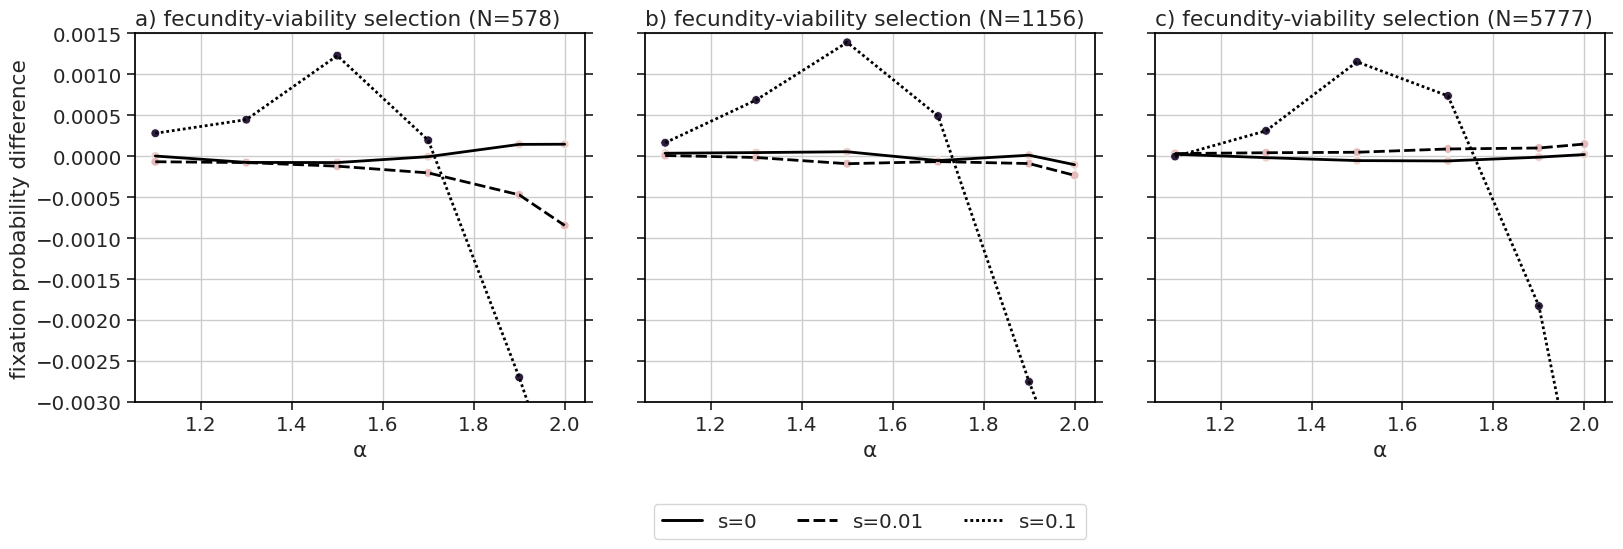

In [27]:
# new 

sns.set_style("whitegrid", {'axes.edgecolor' : '.0001'})

fig, axs = plt.subplots(1, 3, figsize=(16.5, 6), sharey=True)

colors = ["#03045e", "#0077b6", "#00b4d8"]
colors = "black"
color = "black"
linewidth = 2


for i, population_size in enumerate(sinus_population_size):
    difference_frame_population__size = difference_frame[difference_frame["population_size"] == population_size]
    ax = axs[i]
    if i != 1:
        sns.lineplot(data=difference_frame_population__size, x="alpha", y="fecundity-viability",linewidth=2, style="selection_coefficient", ax=ax, color=color, legend=False)
    else:
        sns.lineplot(data=difference_frame_population__size, x="alpha", y="fecundity-viability",linewidth=2, style="selection_coefficient", ax=ax, color=colors)

    sns.scatterplot(data=difference_frame_population__size, x="alpha", y="fecundity-viability",
                    s=40, hue="selection_coefficient", ax=ax, legend=False, color=color).set_title(pos_to_char(i) + ") fecundity-viability selection (N=" + str(population_size) + ")", loc="left")
    ax.set(xlabel='α', ylabel='fixation probability difference')
    ax.grid(True)
    ax.tick_params(bottom=True, top=False, left=True, right=True)
    ax.patch.set_edgecolor('black')  
    #ax.patch.set_linewidth('2') 
    ax.set_ylim(-0.003, 0.0015)

legend_pos=-0.25    
ncol=3
ax=axs[1]
box = ax.get_position()
h, l = ax.get_legend_handles_labels()
leg = ax.legend(handles=h, loc='upper center',bbox_to_anchor=(0.5, legend_pos), fancybox=True, shadow=False, ncol=ncol, labels=["s=0","s=0.01","s=0.1"])
for line in leg.get_lines():
    line.set_linewidth(2.1) 

plt.tight_layout()
plt.savefig("./figures/difference_probability_fixation_population_sinus_selection_constant.pdf", dpi=500)


## (9) Difference between viability and fecundity selection (sinus shifted population size)

In [28]:
files = os.listdir("../src/simulations/")
files = ["../src/simulations/" + file for file in files]
# filter the times
df_time = [pd.read_csv(file) for file in files if "probability" in file and "shifted_3.1" in file]
df_time = pd.concat(df_time).reset_index()
df = df_time[df_time["population_size_model"] == "sinus"]

In [29]:
fecundity_constant = df[df["selection_type"] == "fecundity_constant"]
viability_constant = df[df["selection_type"] == "viability_constant"]

selection_coefficients = [0, 0.01, 0.1]

difference_frame = []
for population_size in sinus_population_size:

    for selection_coefficient in selection_coefficients:
        
        constant = pd.concat([fecundity_constant, viability_constant]).reset_index()
        constant = constant[constant["population_size"] == population_size]
        constant = constant[constant["selection_coefficient"] == selection_coefficient]

        for alpha in [1.1, 1.3, 1.5, 1.7, 1.9, 2.0]:
            try:
                alpha_frame = constant[constant["parameter"] == alpha]
                fc = alpha_frame[alpha_frame["selection_type"] == "fecundity_constant"]
                vc = alpha_frame[alpha_frame["selection_type"] == "viability_constant"]
                diff = fc.fixation_probability.item() - vc.fixation_probability.item()
                #diff_std = np.mean([fc.standard_deviation.item(), vc.standard_deviation.item()])
                #print(alpha, diff, population_size, selection_coefficient)

                difference_frame.append([alpha, diff, population_size, selection_coefficient])
            except:
                pass
            
difference_frame = pd.DataFrame(difference_frame, columns=["alpha", "fecundity-viability", "population_size", "selection_coefficient"])

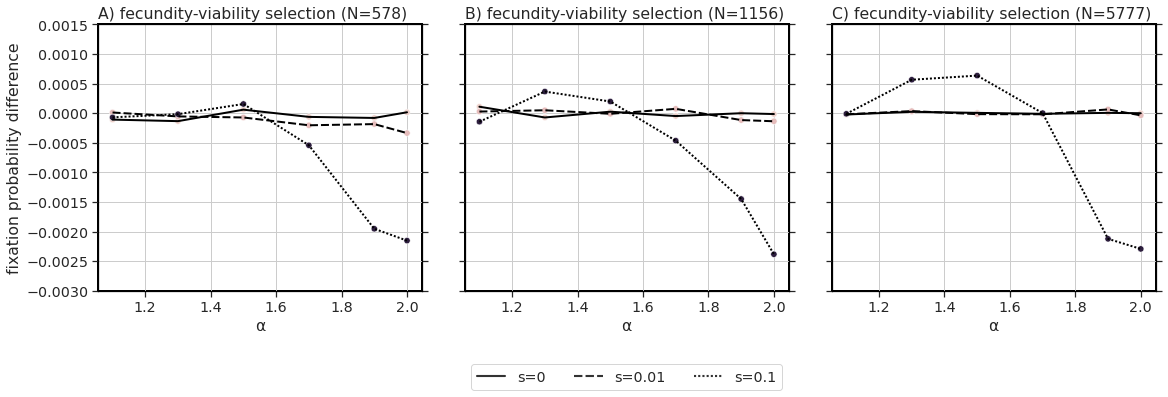

In [ ]:
sns.set_style("whitegrid", {'axes.edgecolor' : '.0001'})

fig, axs = plt.subplots(1, 3, figsize=(16.5, 6), sharey=True)

colors = ["#03045e", "#0077b6", "#00b4d8"]
colors = "black"
color = "black"
linewidth = 2


for i, population_size in enumerate(sinus_population_size):
    difference_frame_population__size = difference_frame[difference_frame["population_size"] == population_size]
    ax = axs[i]
    if i != 1:
        sns.lineplot(data=difference_frame_population__size, x="alpha", y="fecundity-viability",linewidth=2, style="selection_coefficient", ax=ax, color=color, legend=False)
    else:
        sns.lineplot(data=difference_frame_population__size, x="alpha", y="fecundity-viability",linewidth=2, style="selection_coefficient", ax=ax, color=colors)

    sns.scatterplot(data=difference_frame_population__size, x="alpha", y="fecundity-viability",
                    s=40, hue="selection_coefficient", ax=ax, legend=False, color=color).set_title(pos_to_char(i) + ") fecundity-viability selection (N=" + str(population_size) + ")", loc="left")
    ax.set(xlabel='α', ylabel='fixation probability difference')
    ax.grid(True)
    ax.tick_params(bottom=True, top=False, left=True, right=True)
    ax.patch.set_edgecolor('black')  
    #ax.patch.set_linewidth('2') 
    ax.set_ylim(-0.003, 0.0015)

legend_pos=-0.25    
ncol=3
ax=axs[1]
box = ax.get_position()
h, l = ax.get_legend_handles_labels()
leg = ax.legend(handles=h, loc='upper center',bbox_to_anchor=(0.5, legend_pos), fancybox=True, shadow=False, ncol=ncol, labels=["s=0","s=0.01","s=0.1"])
for line in leg.get_lines():
    line.set_linewidth(2.1) 

plt.tight_layout()
plt.savefig("./figures/difference_probability_fixation_population_shifted_sinus_selection_constant.pdf", dpi=500)


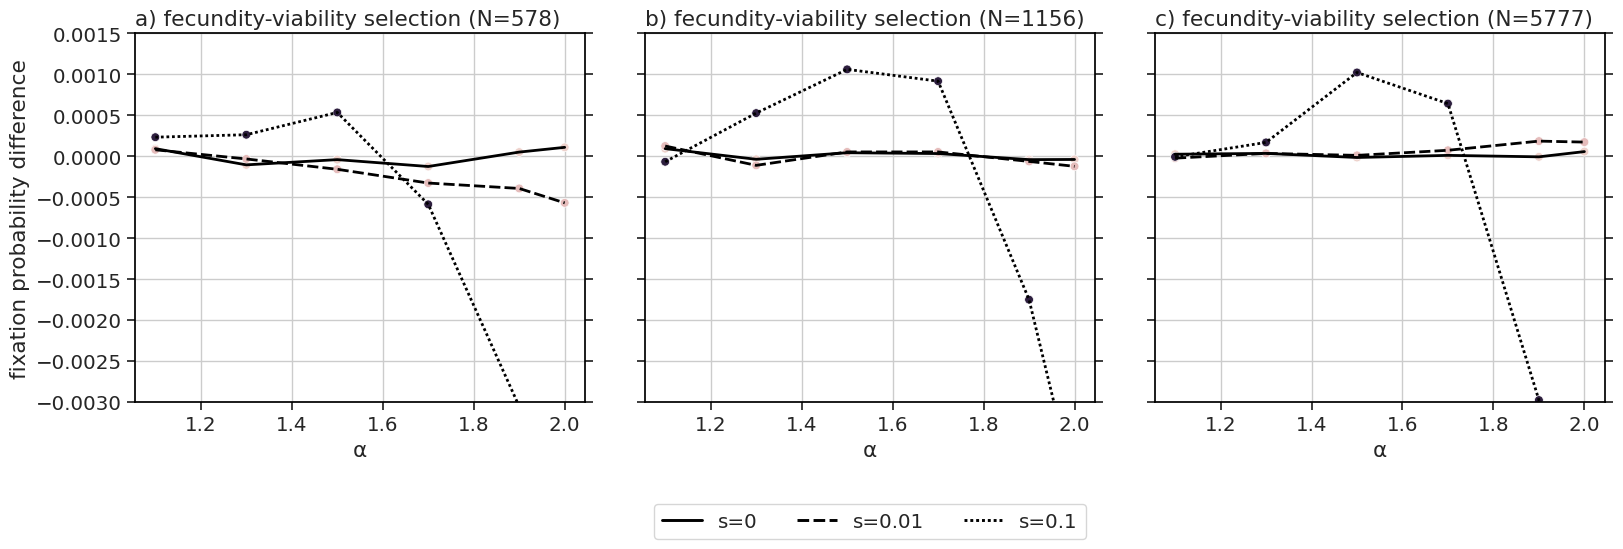

In [30]:
# new 
sns.set_style("whitegrid", {'axes.edgecolor' : '.0001'})

fig, axs = plt.subplots(1, 3, figsize=(16.5, 6), sharey=True)

colors = ["#03045e", "#0077b6", "#00b4d8"]
colors = "black"
color = "black"
linewidth = 2


for i, population_size in enumerate(sinus_population_size):
    difference_frame_population__size = difference_frame[difference_frame["population_size"] == population_size]
    ax = axs[i]
    if i != 1:
        sns.lineplot(data=difference_frame_population__size, x="alpha", y="fecundity-viability",linewidth=2, style="selection_coefficient", ax=ax, color=color, legend=False)
    else:
        sns.lineplot(data=difference_frame_population__size, x="alpha", y="fecundity-viability",linewidth=2, style="selection_coefficient", ax=ax, color=colors)

    sns.scatterplot(data=difference_frame_population__size, x="alpha", y="fecundity-viability",
                    s=40, hue="selection_coefficient", ax=ax, legend=False, color=color).set_title(pos_to_char(i) + ") fecundity-viability selection (N=" + str(population_size) + ")", loc="left")
    ax.set(xlabel='α', ylabel='fixation probability difference')
    ax.grid(True)
    ax.tick_params(bottom=True, top=False, left=True, right=True)
    ax.patch.set_edgecolor('black')  
    #ax.patch.set_linewidth('2') 
    ax.set_ylim(-0.003, 0.0015)

legend_pos=-0.25    
ncol=3
ax=axs[1]
box = ax.get_position()
h, l = ax.get_legend_handles_labels()
leg = ax.legend(handles=h, loc='upper center',bbox_to_anchor=(0.5, legend_pos), fancybox=True, shadow=False, ncol=ncol, labels=["s=0","s=0.01","s=0.1"])
for line in leg.get_lines():
    line.set_linewidth(2.1) 

plt.tight_layout()
plt.savefig("./figures/difference_probability_fixation_population_shifted_sinus_selection_constant.pdf", dpi=500)


## (10) Viability selection (sinus selection), (11) Fecundity selection (sinus selection)

In [32]:
files = os.listdir("../src/simulations/")
files = ["../src/simulations/" + file for file in files]
# filter the times
df_time = [pd.read_csv(file) for file in files if "probability" in file and "shifted_0.0" in file]
df_time = pd.concat(df_time).reset_index()

df = df_time[df_time["population_size_model"] == "constant"]

In [33]:
viability_constant_df = df[df["selection_type"] == "viability_sinus"].reset_index()
fecundity_constant_df = df[df["selection_type"] == "fecundity_sinus"].reset_index()
selection_coefficients = viability_constant_df.selection_coefficient.unique().tolist() 

/tmp/ipykernel_2960852/2613465347.py:16: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=viability_constant_population_size, x="parameter", y="fixation_probability", style="selection_coefficient", ax=ax,
/tmp/ipykernel_2960852/2613465347.py:18: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=viability_constant_population_size, x="parameter", y="fixation_probability", style="selection_coefficient", ax=ax,
/tmp/ipykernel_2960852/2613465347.py:23: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=viability_constant_population_size,x="parameter", y="fixation_probability", style="selection_coefficient", ax=ins,
/tmp/ipykernel_2960852/2613465347.py:45: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=fecundity_constant_population_size, x="parameter", y="fixation_probability", style="selection_coeffi

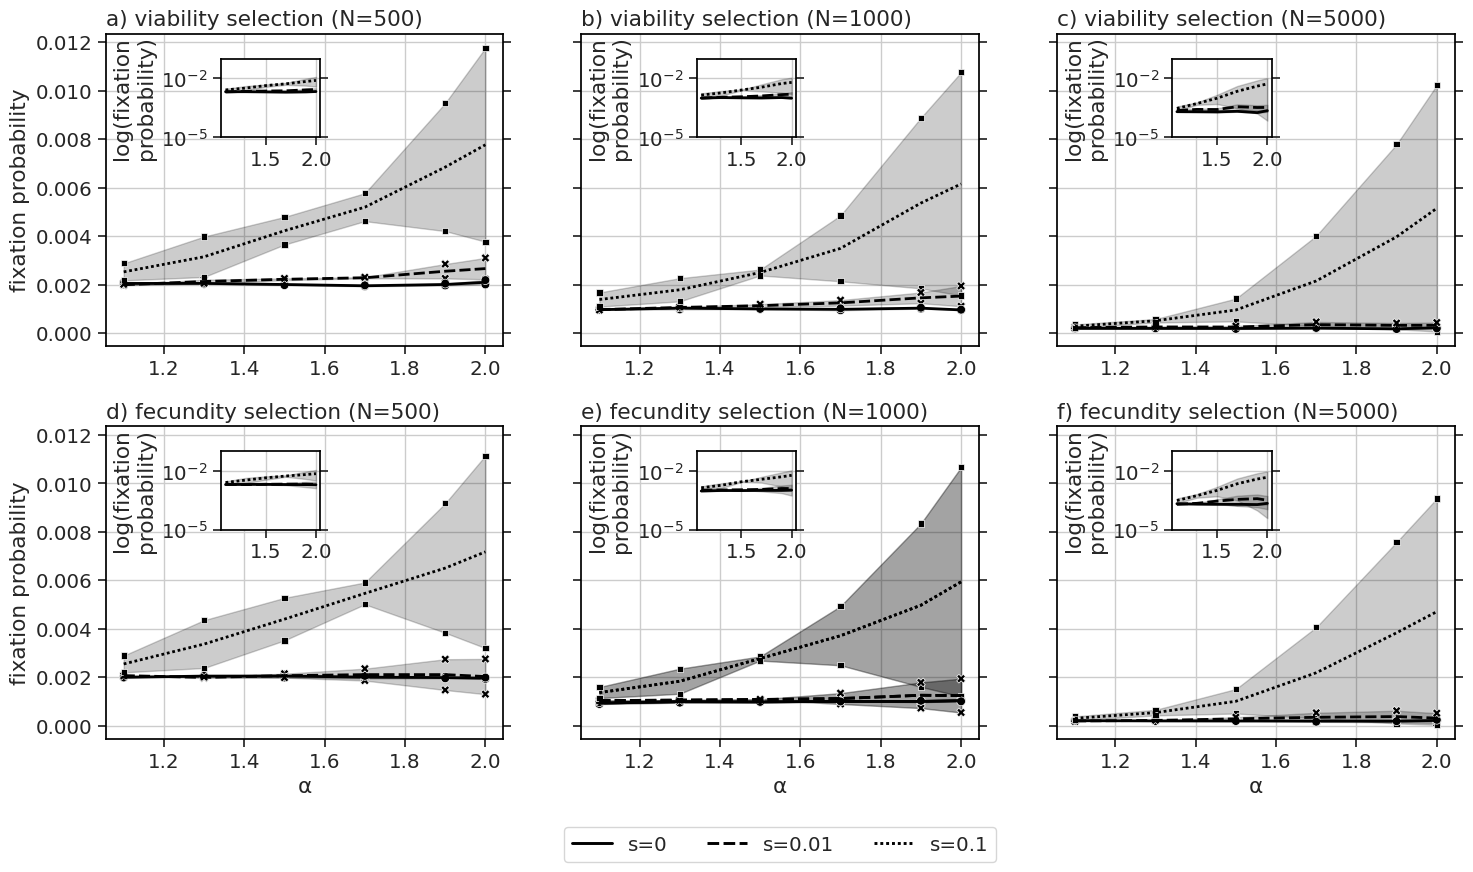

In [34]:
sns.set(font_scale = 1.3, style="whitegrid")
sns.set_style("whitegrid", {'axes.edgecolor' : '.0001'})

population_sizes = [500,1000,5000]

fig, axs = plt.subplots(2, 3, figsize=(15, 9), sharey=True)

colors = ["#03045e", "#0077b6", "#00b4d8"]
colors = "black"
color = "black"
linewidth = 2

for i, population_size in enumerate(population_sizes):
    ax = axs[0][i]
    viability_constant_population_size = df = viability_constant_df[viability_constant_df["population_size"] == population_size]
    sns.lineplot(data=viability_constant_population_size, x="parameter", y="fixation_probability", style="selection_coefficient", ax=ax,
                 palette=colors, linewidth=linewidth, legend=False,  color = color)
    sns.scatterplot(data=viability_constant_population_size, x="parameter", y="fixation_probability", style="selection_coefficient", ax=ax,
                    palette=colors, s=40, legend=False,  color = color).set_title(pos_to_char(i) + ") viability selection (N=" + str(population_size) + ")",  loc="left")

    
    ins = axs[0][i].inset_axes([0.29, 0.67, 0.25, 0.25])
    sns.lineplot(data=viability_constant_population_size,x="parameter", y="fixation_probability", style="selection_coefficient", ax=ins,
                 palette=colors, linewidth=linewidth, legend=False,  color = color)
    
    
    ins.set_yscale("log")
    ins.set(ylim=(0.00001, 0.1), xlabel='', ylabel='log(fixation\nprobability)')
    ins.patch.set_edgecolor('black')  
    #ins.patch.set_linewidth('2')
    ins.tick_params(bottom=True, top=False, left=True, right=True)
    

    
    ax.tick_params(bottom=True, top=False, left=True, right=True)
    ax.patch.set_edgecolor('black')  
    #ax.grid(True)
    #ax.patch.set_linewidth('2')
    ax.set(xlabel='', ylabel='fixation probability')
    
    
    ax = axs[1][i]
    fecundity_constant_population_size = df = fecundity_constant_df[fecundity_constant_df["population_size"] == population_size]
    
    sns.lineplot(data=fecundity_constant_population_size, x="parameter", y="fixation_probability", style="selection_coefficient", ax=ax,
                 palette=colors, linewidth=linewidth, legend=False,  color = color)
    
    if i == 1:
        ax = sns.lineplot(data=fecundity_constant_population_size, x="parameter", y="fixation_probability", style="selection_coefficient", ax=ax, linewidth=linewidth, legend=True, color = color)

            
    sns.scatterplot(data=fecundity_constant_population_size, x="parameter", y="fixation_probability", style="selection_coefficient", ax=ax, palette=colors, s=40, legend=False, color = color).set_title(pos_to_char(i+3) + ") fecundity selection (N=" + str(population_size) + ")", loc="left")

    
    ins = axs[1][i].inset_axes([0.29, 0.67, 0.25, 0.25])
    sns.lineplot(data=fecundity_constant_population_size,x="parameter", y="fixation_probability", style="selection_coefficient", ax=ins,
                 palette=colors, linewidth=linewidth, legend=False,  color = color)

    ins.set_yscale("log")
    ins.set(ylim=(0.00001, 0.1), xlabel='', ylabel='log(fixation\nprobability)')
    ins.patch.set_edgecolor('black')  
    ins.tick_params(bottom=True, top=False, left=True, right=True)
    #ins.patch.set_linewidth('2')
    
    ax.tick_params(bottom=True, top=False, left=True, right=True)
    ax.patch.set_edgecolor('black')  
    ax.grid(True)
    #ax.patch.set_linewidth('2')
    ax.set(xlabel='α', ylabel='fixation probability')
    
    

legend_pos=-0.25    
ncol=3
ax=axs[1][1]
box = ax.get_position()
h, l = ax.get_legend_handles_labels()
leg = ax.legend(handles=h, loc='upper center',bbox_to_anchor=(0.5, legend_pos), fancybox=True, shadow=False, ncol=ncol, labels=["s=0","s=0.01","s=0.1"])
for line in leg.get_lines():
    line.set_linewidth(2.1) 
            

plt.tight_layout()
plt.savefig("./figures/probability_fixation_population_constant_selection_sinus.pdf", dpi=500)


## (12) Viability selection (shifted sinus selection), (13) Fecundity selection (shifted sinus selection)

In [36]:
files = os.listdir("../src/simulations/")
files = ["../src/simulations/" + file for file in files]
# filter the times
df_time = [pd.read_csv(file) for file in files if "probability" in file and "shifted_3.1" in file]
df_time = pd.concat(df_time).reset_index()

df = df_time[df_time["population_size_model"] == "constant"]

In [37]:
viability_constant_df = df[df["selection_type"] == "viability_sinus"].reset_index()
fecundity_constant_df = df[df["selection_type"] == "fecundity_sinus"].reset_index()
selection_coefficients = viability_constant_df.selection_coefficient.unique().tolist() 

/tmp/ipykernel_2960852/1965086990.py:16: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=viability_constant_population_size, x="parameter", y="fixation_probability", style="selection_coefficient", ax=ax,
/tmp/ipykernel_2960852/1965086990.py:18: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=viability_constant_population_size, x="parameter", y="fixation_probability", style="selection_coefficient", ax=ax,
/tmp/ipykernel_2960852/1965086990.py:23: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=viability_constant_population_size,x="parameter", y="fixation_probability", style="selection_coefficient", ax=ins,
/tmp/ipykernel_2960852/1965086990.py:45: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=fecundity_constant_population_size, x="parameter", y="fixation_probability", style="selection_coeffi

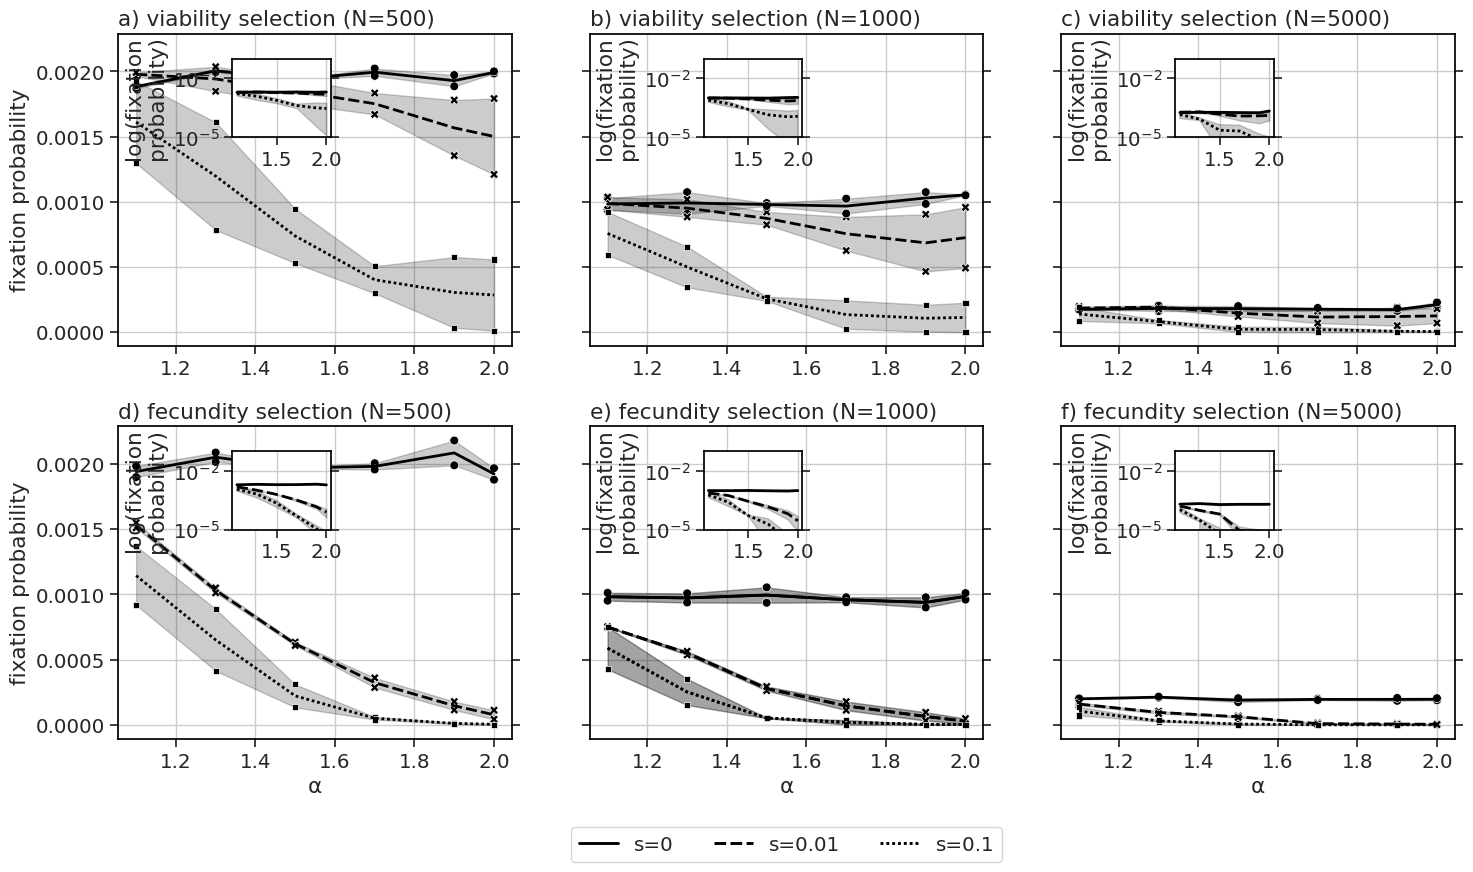

In [38]:
sns.set(font_scale = 1.3, style="whitegrid")
sns.set_style("whitegrid", {'axes.edgecolor' : '.0001'})

population_sizes = [500,1000,5000]

fig, axs = plt.subplots(2, 3, figsize=(15, 9), sharey=True)

colors = ["#03045e", "#0077b6", "#00b4d8"]
colors = "black"
color = "black"
linewidth = 2

for i, population_size in enumerate(population_sizes):
    ax = axs[0][i]
    viability_constant_population_size = df = viability_constant_df[viability_constant_df["population_size"] == population_size]
    sns.lineplot(data=viability_constant_population_size, x="parameter", y="fixation_probability", style="selection_coefficient", ax=ax,
                 palette=colors, linewidth=linewidth, legend=False,  color = color)
    sns.scatterplot(data=viability_constant_population_size, x="parameter", y="fixation_probability", style="selection_coefficient", ax=ax,
                    palette=colors, s=40, legend=False,  color = color).set_title(pos_to_char(i) + ") viability selection (N=" + str(population_size) + ")",  loc="left")

    
    ins = axs[0][i].inset_axes([0.29, 0.67, 0.25, 0.25])
    sns.lineplot(data=viability_constant_population_size,x="parameter", y="fixation_probability", style="selection_coefficient", ax=ins,
                 palette=colors, linewidth=linewidth, legend=False,  color = color)
    
    
    ins.set_yscale("log")
    ins.set(ylim=(0.00001, 0.1), xlabel='', ylabel='log(fixation\nprobability)')
    ins.patch.set_edgecolor('black')  
    #ins.patch.set_linewidth('2')
    ins.tick_params(bottom=True, top=False, left=True, right=True)
    

    
    ax.tick_params(bottom=True, top=False, left=True, right=True)
    ax.patch.set_edgecolor('black')  
    #ax.grid(True)
    #ax.patch.set_linewidth('2')
    ax.set(xlabel='', ylabel='fixation probability')
    
    
    ax = axs[1][i]
    fecundity_constant_population_size = df = fecundity_constant_df[fecundity_constant_df["population_size"] == population_size]
    
    sns.lineplot(data=fecundity_constant_population_size, x="parameter", y="fixation_probability", style="selection_coefficient", ax=ax,
                 palette=colors, linewidth=linewidth, legend=False,  color = color)
    
    if i == 1:
        ax = sns.lineplot(data=fecundity_constant_population_size, x="parameter", y="fixation_probability", style="selection_coefficient", ax=ax, linewidth=linewidth, legend=True, color = color)

            
    sns.scatterplot(data=fecundity_constant_population_size, x="parameter", y="fixation_probability", style="selection_coefficient", ax=ax, palette=colors, s=40, legend=False, color = color).set_title(pos_to_char(i+3) + ") fecundity selection (N=" + str(population_size) + ")", loc="left")

    
    ins = axs[1][i].inset_axes([0.29, 0.67, 0.25, 0.25])
    sns.lineplot(data=fecundity_constant_population_size,x="parameter", y="fixation_probability", style="selection_coefficient", ax=ins,
                 palette=colors, linewidth=linewidth, legend=False,  color = color)

    ins.set_yscale("log")
    ins.set(ylim=(0.00001, 0.1), xlabel='', ylabel='log(fixation\nprobability)')
    ins.patch.set_edgecolor('black')  
    ins.tick_params(bottom=True, top=False, left=True, right=True)
    #ins.patch.set_linewidth('2')
    
    ax.tick_params(bottom=True, top=False, left=True, right=True)
    ax.patch.set_edgecolor('black')  
    ax.grid(True)
    #ax.patch.set_linewidth('2')
    ax.set(xlabel='α', ylabel='fixation probability')
    

legend_pos=-0.25    
ncol=3
ax=axs[1][1]
box = ax.get_position()
h, l = ax.get_legend_handles_labels()
leg = ax.legend(handles=h, loc='upper center',bbox_to_anchor=(0.5, legend_pos), fancybox=True, shadow=False, ncol=ncol, labels=["s=0","s=0.01","s=0.1"])
for line in leg.get_lines():
    line.set_linewidth(2.1) 
            

plt.tight_layout()
plt.savefig("./figures/probability_fixation_population_constant_selection_shifted_sinus.pdf", dpi=500)


## (14) Difference between viability and fecundity selection (sinus selection)

In [39]:
files = os.listdir("../src/simulations/")
files = ["../src/simulations/" + file for file in files]
# filter the times
df_time = [pd.read_csv(file) for file in files if "probability" in file and "shifted_0.0" in file]
df_time = pd.concat(df_time).reset_index()

df = df_time[df_time["population_size_model"] == "constant"]
fecundity_constant = df[df["selection_type"] == "fecundity_sinus"]#.reset_index()
viability_constant = df[df["selection_type"] == "viability_sinus"]#.reset_index()

In [40]:
selection_coefficients = viability_constant.selection_coefficient.unique()
population_sizes = [500, 1000, 5000]

In [41]:
difference_frame = []
for population_size in population_sizes:

    for selection_coefficient in selection_coefficients:
        
        constant = pd.concat([fecundity_constant, viability_constant]).reset_index()
        constant = constant[constant["population_size"] == population_size]
        constant = constant[constant["selection_coefficient"] == selection_coefficient]

        for alpha in [1.1, 1.3, 1.5, 1.7, 1.9, 2.0]:
            try:
                alpha_frame = constant[constant["parameter"] == alpha]
                fc = alpha_frame[alpha_frame["selection_type"] == "fecundity_sinus"]
                vc = alpha_frame[alpha_frame["selection_type"] == "viability_sinus"]
                diff = fc.fixation_probability.item() - vc.fixation_probability.item()
                #diff_std = np.mean([fc.standard_deviation.item(), vc.standard_deviation.item()])
                #print(alpha, diff, population_size, selection_coefficient)

                difference_frame.append([alpha, diff, population_size, selection_coefficient])
            except:
                pass

difference_frame = pd.DataFrame(difference_frame, columns=["alpha", "fecundity-viability", "population_size", "selection_coefficient"])

/tmp/ipykernel_2960852/4258975355.py:34: UserWarning: Mismatched number of handles and labels: len(handles) = 0 len(labels) = 1
  leg = ax.legend(handles=h, loc='upper center',bbox_to_anchor=(0.5, legend_pos), fancybox=True, shadow=False, ncol=ncol, labels=["s=0"])
/tmp/ipykernel_2960852/4258975355.py:34: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  leg = ax.legend(handles=h, loc='upper center',bbox_to_anchor=(0.5, legend_pos), fancybox=True, shadow=False, ncol=ncol, labels=["s=0"])


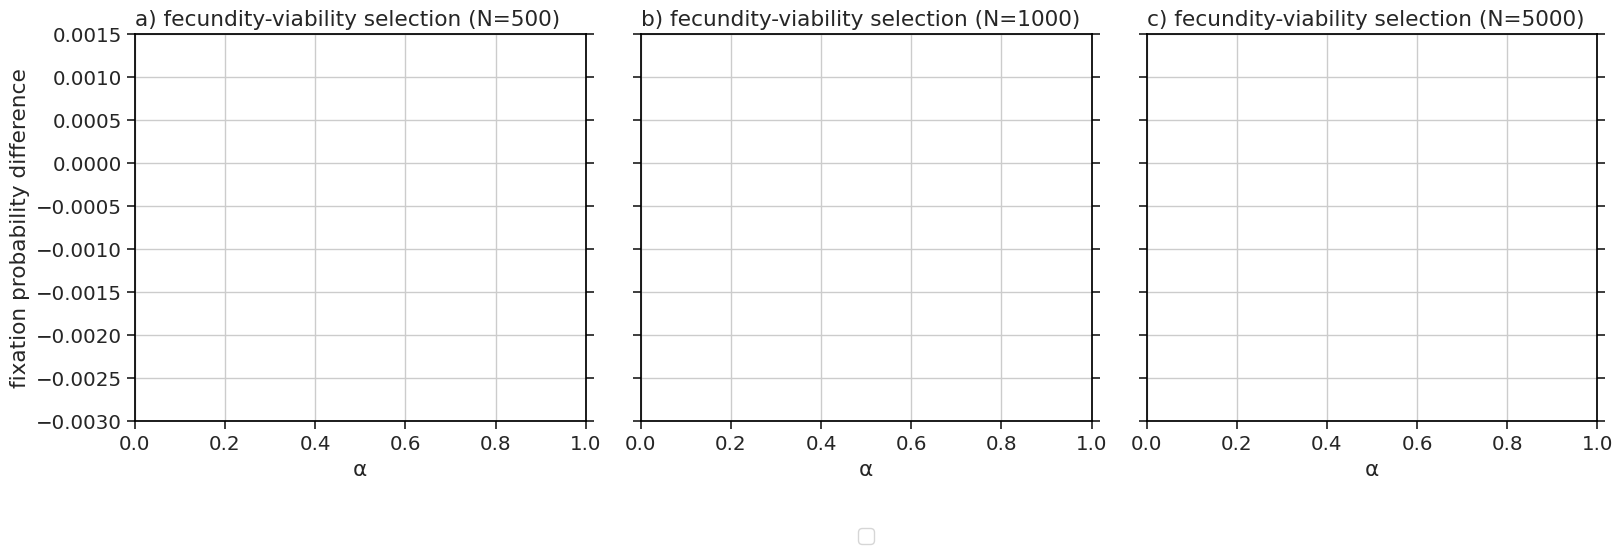

In [42]:
sns.set_style("whitegrid", {'axes.edgecolor' : '.0001'})

fig, axs = plt.subplots(1, 3, figsize=(16.5, 6), sharey=True)

colors = ["#03045e", "#0077b6", "#00b4d8"]
colors = "black"
color = "black"
linewidth = 2


for i, population_size in enumerate(population_sizes):
    difference_frame_population__size = difference_frame[difference_frame["population_size"] == population_size]
    ax = axs[i]
    if i != 1:
        sns.lineplot(data=difference_frame_population__size, x="alpha", y="fecundity-viability",linewidth=2, style="selection_coefficient", ax=ax, color=color, legend=False)
    else:
        sns.lineplot(data=difference_frame_population__size, x="alpha", y="fecundity-viability",linewidth=2, style="selection_coefficient", ax=ax, color=colors)

    sns.scatterplot(data=difference_frame_population__size, x="alpha", y="fecundity-viability", s=40, style="selection_coefficient", ax=ax, 
                    legend=False, color=color).set_title(pos_to_char(i) + ") fecundity-viability selection (N=" + str(population_size) + ")", loc="left")
    
    ax.set(xlabel='α', ylabel='fixation probability difference')
    ax.grid(True)
    ax.tick_params(bottom=True, top=False, left=True, right=True)
    ax.patch.set_edgecolor('black')  
    #ax.patch.set_linewidth('2') 
    ax.set_ylim(-0.003, 0.0015)

legend_pos=-0.25    
ncol=3
ax=axs[1]
box = ax.get_position()
h, l = ax.get_legend_handles_labels()
leg = ax.legend(handles=h, loc='upper center',bbox_to_anchor=(0.5, legend_pos), fancybox=True, shadow=False, ncol=ncol, labels=["s=0"])

for line in leg.get_lines():
    line.set_linewidth(2.1) 

plt.tight_layout()
plt.savefig("./figures/difference_probability_fixation_population_constant_selection_sinus.pdf", dpi=500)


## (15) Difference between viability and fecundity selection (shifted sinus selection)

In [43]:
files = os.listdir("../src/simulations/")
files = ["../src/simulations/" + file for file in files]
# filter the times
df_time = [pd.read_csv(file) for file in files if "probability" in file and "shifted_3.1" in file]
df_time = pd.concat(df_time).reset_index()

df = df_time[df_time["population_size_model"] == "constant"]
fecundity_constant = df[df["selection_type"] == "fecundity_sinus"]#.reset_index()
viability_constant = df[df["selection_type"] == "viability_sinus"]#.reset_index()

In [44]:


difference_frame = []
for population_size in [500, 1000, 5000]:

    for selection_coefficient in selection_coefficients:
        
        constant = pd.concat([fecundity_constant, viability_constant]).reset_index()
        constant = constant[constant["population_size"] == population_size]
        constant = constant[constant["selection_coefficient"] == selection_coefficient]

        for alpha in [1.1, 1.3, 1.5, 1.7, 1.9, 2.0]:
            try:
                alpha_frame = constant[constant["parameter"] == alpha]
                fc = alpha_frame[alpha_frame["selection_type"] == "fecundity_sinus"]
                vc = alpha_frame[alpha_frame["selection_type"] == "viability_sinus"]
                diff = fc.fixation_probability.item() - vc.fixation_probability.item()
                #diff_std = np.mean([fc.standard_deviation.item(), vc.standard_deviation.item()])
                #print(alpha, diff, population_size, selection_coefficient)

                difference_frame.append([alpha, diff, population_size, selection_coefficient])
            except:
                pass
            
difference_frame = pd.DataFrame(difference_frame, columns=["alpha", "fecundity-viability", "population_size", "selection_coefficient"])

/tmp/ipykernel_2960852/3421993628.py:34: UserWarning: Mismatched number of handles and labels: len(handles) = 0 len(labels) = 3
  leg = ax.legend(handles=h, loc='upper center',bbox_to_anchor=(0.5, legend_pos), fancybox=True, shadow=False, ncol=ncol, labels=["s=0","s=0.01","s=0.1"])
/tmp/ipykernel_2960852/3421993628.py:34: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  leg = ax.legend(handles=h, loc='upper center',bbox_to_anchor=(0.5, legend_pos), fancybox=True, shadow=False, ncol=ncol, labels=["s=0","s=0.01","s=0.1"])


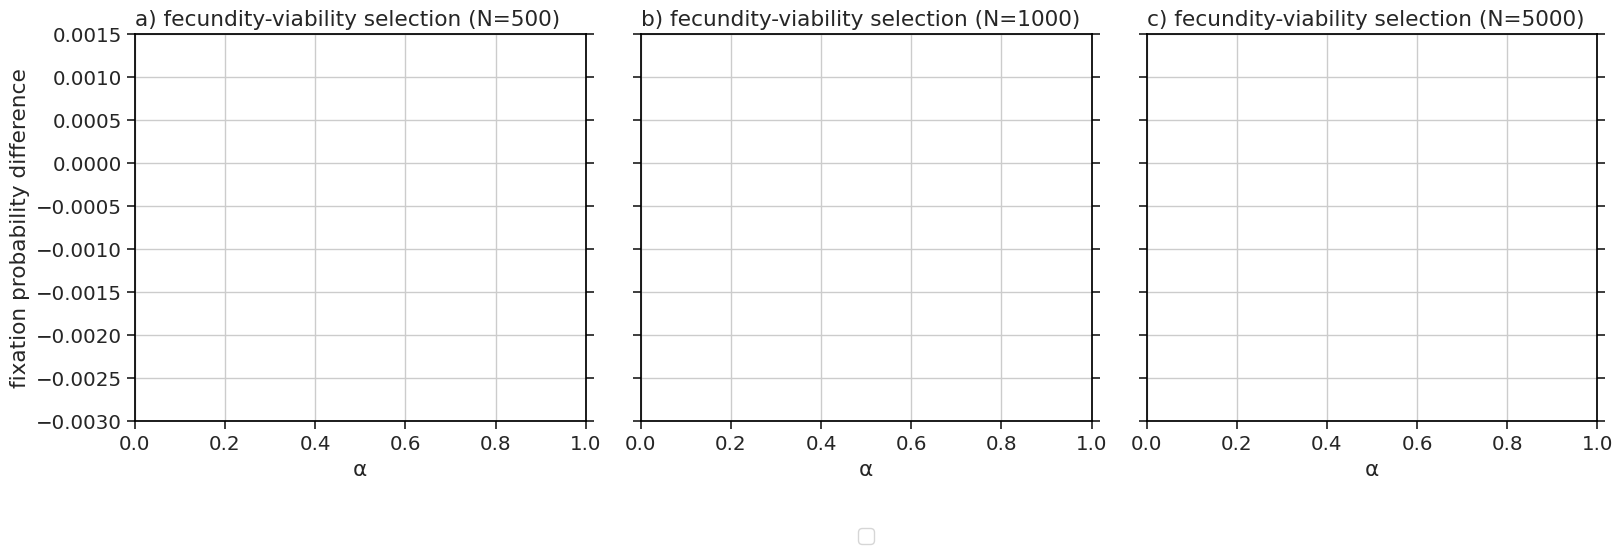

In [45]:
sns.set_style("whitegrid", {'axes.edgecolor' : '.0001'})

fig, axs = plt.subplots(1, 3, figsize=(16.5, 6), sharey=True)

colors = ["#03045e", "#0077b6", "#00b4d8"]
colors = "black"
color = "black"
linewidth = 2


for i, population_size in enumerate(population_sizes):
    difference_frame_population__size = difference_frame[difference_frame["population_size"] == population_size]
    ax = axs[i]
    if i != 1:
        sns.lineplot(data=difference_frame_population__size, x="alpha", y="fecundity-viability",linewidth=2, style="selection_coefficient", ax=ax, color=color, legend=False)
    else:
        sns.lineplot(data=difference_frame_population__size, x="alpha", y="fecundity-viability",linewidth=2, style="selection_coefficient", ax=ax, color=colors)

    sns.scatterplot(data=difference_frame_population__size, x="alpha", y="fecundity-viability",
                    s=40, style="selection_coefficient", ax=ax, legend=False, color=color).set_title(pos_to_char(i) + ") fecundity-viability selection (N=" + str(population_size) + ")", loc="left")
    
    ax.set(xlabel='α', ylabel='fixation probability difference')
    ax.grid(True)
    ax.tick_params(bottom=True, top=False, left=True, right=True)
    ax.patch.set_edgecolor('black')  
    #ax.patch.set_linewidth('2') 
    ax.set_ylim(-0.003, 0.0015)

legend_pos=-0.25    
ncol=3
ax=axs[1]
box = ax.get_position()
h, l = ax.get_legend_handles_labels()
leg = ax.legend(handles=h, loc='upper center',bbox_to_anchor=(0.5, legend_pos), fancybox=True, shadow=False, ncol=ncol, labels=["s=0","s=0.01","s=0.1"])
for line in leg.get_lines():
    line.set_linewidth(2.1) 

plt.tight_layout()
plt.savefig("./figures/difference_probability_fixation_population_constant_selection_shifted_sinus.pdf", dpi=500)


In [47]:
#files = os.listdir("./simulations_old_floor/")
#files = ["./simulations_old_floor/" + file for file in files if "probability" in file]
from copy import deepcopy
files = os.listdir("../src/simulations/")
files = ["../src/simulations/" + file for file in files if "probability" in file and "adapted" not in file]

# filter the times
df_time = [pd.read_csv(file) for file in files if "probability" in file]
df_time = pd.concat(df_time).reset_index()

df = df_time[df_time["population_size_model"] == "constant"]

viability_constant_df = df[df["selection_type"] == "viability_constant"].reset_index()
fecundity_constant_df = df[df["selection_type"] == "fecundity_constant"].reset_index()
selection_coefficients = viability_constant_df.selection_coefficient.unique().tolist() 
fecundity_constant_df["adapted_alpha"] = False
fecundity_constant_df_non_adapted_alpha = deepcopy(fecundity_constant_df)

In [48]:
#files = os.listdir("./simulations_old_floor/")
#files = ["./simulations_old_floor/" + file for file in files if "probability" in file]

files = os.listdir("../src/simulations/")
files = ["../src/simulations/" + file for file in files if "adapted" in file and "probability" in file]

# filter the times
df_time = [pd.read_csv(file) for file in files if "probability" in file]
df_time = pd.concat(df_time).reset_index()

df = df_time[df_time["population_size_model"] == "constant"]

viability_constant_df = df[df["selection_type"] == "viability_constant"].reset_index()
fecundity_constant_df = df[df["selection_type"] == "fecundity_constant"].reset_index()

fecundity_constant_df_adapted_alpha = deepcopy(fecundity_constant_df)
selection_coefficients = viability_constant_df.selection_coefficient.unique().tolist() 

In [49]:
from copy import deepcopy

/tmp/ipykernel_2960852/465688826.py:17: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=fecundity_constant_population_size, x="parameter", y="fixation_probability", style="selection_coefficient", ax=ax,
/tmp/ipykernel_2960852/465688826.py:24: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=fecundity_constant_population_size, x="parameter", y="fixation_probability", style="selection_coefficient", ax=ax, palette=colors, s=40, legend=False, color = color).set_title(pos_to_char(i) + ") fecundity selection (N=" + str(population_size) + ")", loc="left")
/tmp/ipykernel_2960852/465688826.py:28: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=fecundity_constant_population_size,x="parameter", y="fixation_probability", style="selection_coefficient", ax=ins,
/tmp/ipykernel_2960852/465688826.py:56: UserWarning: Ignoring `palette` because no `hue` vari

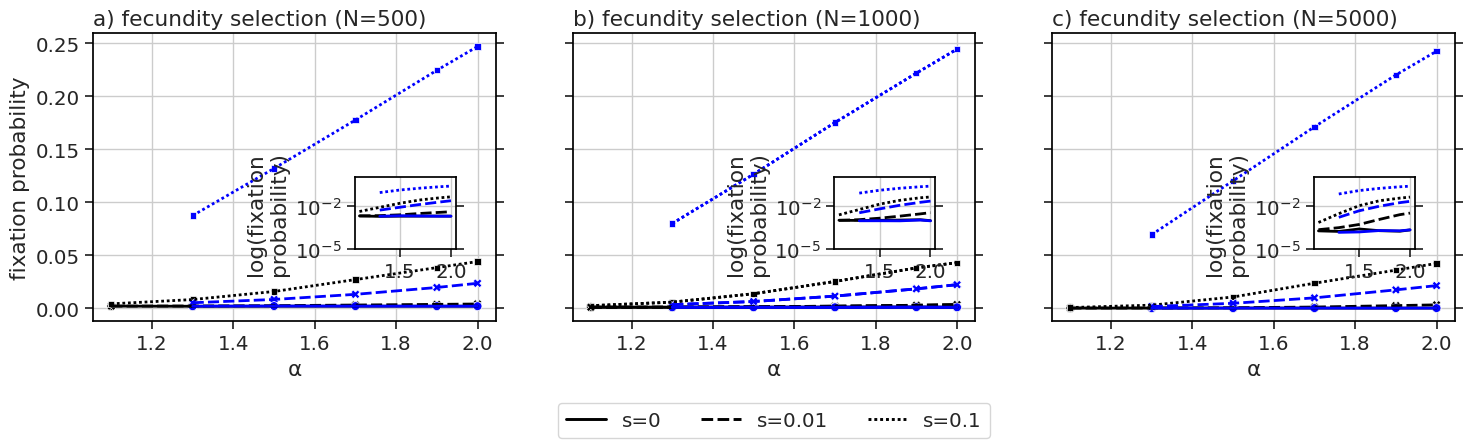

In [50]:
sns.set_style("whitegrid", {'axes.edgecolor' : '.0001'})

fig, axs = plt.subplots(1, 3, figsize=(15, 5), sharey=True)


for i, population_size in enumerate([500, 1000, 5000]):

    fecundity_constant_df = deepcopy(fecundity_constant_df_non_adapted_alpha)
    colors = ["#03045e", "#0077b6", "#00b4d8"]
    colors = "black"
    color = "black"
    linewidth = 2
    
    ax = axs[i]
    fecundity_constant_population_size = df = fecundity_constant_df[fecundity_constant_df["population_size"] == population_size]
    
    sns.lineplot(data=fecundity_constant_population_size, x="parameter", y="fixation_probability", style="selection_coefficient", ax=ax,
                 palette=colors, linewidth=linewidth, legend=False,  color = color)
    
    if i == 1:
        ax = sns.lineplot(data=fecundity_constant_population_size, x="parameter", y="fixation_probability", style="selection_coefficient", ax=ax, linewidth=linewidth, legend=True, color = color)

            
    sns.scatterplot(data=fecundity_constant_population_size, x="parameter", y="fixation_probability", style="selection_coefficient", ax=ax, palette=colors, s=40, legend=False, color = color).set_title(pos_to_char(i) + ") fecundity selection (N=" + str(population_size) + ")", loc="left")

    
    ins = axs[i].inset_axes([0.65, 0.25, 0.25, 0.25])
    sns.lineplot(data=fecundity_constant_population_size,x="parameter", y="fixation_probability", style="selection_coefficient", ax=ins,
                 palette=colors, linewidth=linewidth, legend=False,  color = color)

    #ins.set_yscale("log")
    #ins.set(ylim=(0.00001, 1), xlabel='', ylabel='log(fixation\nprobability)')
    #ins.patch.set_edgecolor('black')  
    #ins.tick_params(bottom=True, top=False, left=True, right=True)
    ##ins.patch.set_linewidth('2')
    
    ax.tick_params(bottom=True, top=False, left=True, right=True)
    ax.patch.set_edgecolor('black')  
    ax.grid(True)
    #ax.patch.set_linewidth('2')
    ax.set(xlabel='α', ylabel='fixation probability')
    
    
    
    
    fecundity_constant_df = deepcopy(fecundity_constant_df_adapted_alpha)

    colors = ["#03045e", "#0077b6", "#00b4d8"]
    colors = "blue"
    color = "blue"
    linewidth = 2
    
    ax = axs[i]
    fecundity_constant_population_size = df = fecundity_constant_df[fecundity_constant_df["population_size"] == population_size]
    
    sns.lineplot(data=fecundity_constant_population_size, x="parameter", y="fixation_probability", style="selection_coefficient", ax=ax,
                 palette=colors, linewidth=linewidth, legend=False,  color = color)
    
    if i == 1:
        ax = sns.lineplot(data=fecundity_constant_population_size, x="parameter", y="fixation_probability", style="selection_coefficient", ax=ax, linewidth=linewidth, legend=True, color = color)

            
    sns.scatterplot(data=fecundity_constant_population_size, x="parameter", y="fixation_probability", style="selection_coefficient", ax=ax, palette=colors, s=40, legend=False, color = color).set_title(pos_to_char(i) + ") fecundity selection (N=" + str(population_size) + ")", loc="left")

    
    #ins = axs[i].inset_axes([0.65, 0.25, 0.25, 0.25])
    sns.lineplot(data=fecundity_constant_population_size,x="parameter", y="fixation_probability", style="selection_coefficient", ax=ins,
                 palette=colors, linewidth=linewidth, legend=False,  color = color)

    ins.set_yscale("log")
    ins.set(ylim=(0.00001, 1), xlabel='', ylabel='log(fixation\nprobability)')
    ins.patch.set_edgecolor('black')  
    ins.tick_params(bottom=True, top=False, left=True, right=True)
    #ins.patch.set_linewidth('2')
    
    ax.tick_params(bottom=True, top=False, left=True, right=True)
    ax.patch.set_edgecolor('black')  
    ax.grid(True)
    #ax.patch.set_linewidth('2')
    ax.set(xlabel='α', ylabel='fixation probability')
    

legend_pos=-0.25    
ncol=3
ax=axs[1]
box = ax.get_position()
h, l = ax.get_legend_handles_labels()
leg = ax.legend(handles=h, loc='upper center',bbox_to_anchor=(0.5, legend_pos), fancybox=True, shadow=False, ncol=ncol, labels=["s=0","s=0.01","s=0.1"])
for line in leg.get_lines():
    line.set_linewidth(2.1) 
            

plt.tight_layout()
plt.savefig("./figures/probability_fixation_population_constant_selection_constant_diff-model.pdf", dpi=500)##